In [26]:
import pandas as pd
import os

# Dossier racine contenant les CSV
racine = r"C:\Projet-IESE5-Localisation\Résultat mesures"

# Dictionnaire pour stocker les 100 mesures centrales de chaque fichier
mesures = {}

# Parcourir récursivement tous les fichiers CSV
for dirpath, dirnames, filenames in os.walk(racine):
    for filename in filenames:
        if filename.endswith(".csv"):
            chemin = os.path.join(dirpath, filename)
            # Chemin relatif pour identifier le fichier
            cle = os.path.relpath(chemin, racine)
            
            df = pd.read_csv(chemin)
            n = len(df)
            
            # Extraire 100 mesures au milieu
            debut = (n - 100) // 2
            fin = debut + 100
            df_milieu = df.iloc[debut:fin]
            
            # Stocker la colonne "Distance (m)"
            mesures[cle] = df_milieu["Distance (m)"].reset_index(drop=True)
            print(f"{cle}: {n} lignes → extrait lignes {debut} à {fin-1}")

# Créer un DataFrame récapitulatif avec toutes les mesures
df_mesures = pd.DataFrame(mesures)
print(f"\nDataFrame final : {df_mesures.shape}")
df_mesures.head(10)

4,5m ds extérieur voiture.csv: 143 lignes → extrait lignes 21 à 120
extérieur\canal 5\10m extérieur ds sans obstacles canal 5.csv: 197 lignes → extrait lignes 48 à 147
extérieur\canal 5\1m extérieur ds sans obstacles canal 5.csv: 200 lignes → extrait lignes 50 à 149
extérieur\canal 5\20m ds sans obstacles canal 5.csv: 128 lignes → extrait lignes 14 à 113
extérieur\canal 5\3m extérieur ds sans obstacles canal 5.csv: 155 lignes → extrait lignes 27 à 126
extérieur\canal 5\5m extérieur ds sans obstacles canal 5.csv: 128 lignes → extrait lignes 14 à 113
extérieur\canal 9\10M ds extérieur obstacle humain.csv: 129 lignes → extrait lignes 14 à 113
extérieur\canal 9\10M ds extérieur sans obstacles.csv: 120 lignes → extrait lignes 10 à 109
extérieur\canal 9\1M ds extérieur obstacle humain.csv: 144 lignes → extrait lignes 22 à 121
extérieur\canal 9\1M ds extérieur sans obstacles.csv: 155 lignes → extrait lignes 27 à 126
extérieur\canal 9\20M ds extérieur sans obstacles.csv: 148 lignes → extrait l

,"4,5m ds extérieur voiture.csv",extérieur\canal 5\10m extérieur ds sans obstacles canal 5.csv,extérieur\canal 5\1m extérieur ds sans obstacles canal 5.csv,extérieur\canal 5\20m ds sans obstacles canal 5.csv,extérieur\canal 5\3m extérieur ds sans obstacles canal 5.csv,extérieur\canal 5\5m extérieur ds sans obstacles canal 5.csv,extérieur\canal 9\10M ds extérieur obstacle humain.csv,extérieur\canal 9\10M ds extérieur sans obstacles.csv,extérieur\canal 9\1M ds extérieur obstacle humain.csv,extérieur\canal 9\1M ds extérieur sans obstacles.csv,...,intérieur\double side\Obstacle métal\5m avec métal.csv,intérieur\double side\Obstacle métal\9m avec métal.csv,intérieur\double side\Sans obstacles\1m sans obstacles.csv,intérieur\double side\Sans obstacles\3m sans obsctacles.csv,intérieur\double side\Sans obstacles\5m sans obstacles.csv,intérieur\double side\Sans obstacles\9m sans obstacles.csv,intérieur\single side\1m single side sans obstacles.csv,intérieur\single side\3m ss sans obstacles.csv,intérieur\single side\5m ss sans obsctacles.csv,intérieur\single side\9m ss sans obstacles.csv
0,5.23,10.15,0.88,20.05,2.95,5.06,10.48,9.95,0.76,0.96,...,5.22,9.12,0.87,3.04,5.10,8.89,0.93,3.05,5.10,9.17
1,5.30,10.11,0.88,20.01,2.93,5.02,10.47,10.05,1.00,0.96,...,5.20,9.08,0.87,3.06,5.09,8.91,0.93,3.03,5.08,9.19
2,4.82,10.11,0.86,19.99,2.92,5.07,10.24,9.99,0.90,0.95,...,5.20,9.09,0.92,3.04,5.10,8.88,0.95,3.03,5.06,9.15
3,4.84,10.10,0.90,19.97,2.91,5.04,10.72,10.14,0.97,0.94,...,5.23,9.10,0.89,3.06,5.09,8.90,0.93,3.05,5.00,9.09
4,5.15,10.14,0.88,20.03,2.92,5.06,10.40,10.54,0.86,0.96,...,5.23,9.08,0.90,3.05,5.08,8.90,0.91,3.05,5.06,9.11
5,5.38,10.13,0.88,19.98,2.90,5.00,10.70,10.07,0.88,0.98,...,5.25,9.09,0.88,3.05,5.11,8.90,0.91,3.07,5.00,9.13
6,5.20,10.12,0.89,20.05,2.91,5.06,10.65,10.02,0.84,0.92,...,5.22,9.09,0.87,3.04,5.06,8.91,0.97,3.07,5.06,9.17
7,5.45,10.12,0.90,19.99,2.92,5.06,10.36,10.11,0.79,0.98,...,5.25,9.11,0.90,3.06,5.08,8.92,0.99,3.07,5.04,9.17
8,4.79,10.12,0.88,20.02,2.95,5.06,10.52,10.03,0.83,0.94,...,5.23,9.08,0.89,3.04,5.03,9.01,0.86,3.07,5.08,9.11
9,4.86,10.09,0.90,19.98,2.93,5.05,10.30,10.30,0.76,0.95,...,5.23,9.14,0.89,3.04,5.11,8.99,0.88,3.03,4.97,9.13


In [27]:
import numpy as np
import re

# Extraire la vraie distance depuis le nom du fichier (ex: "1m sans obstacles.csv" → 1.0)
def extraire_distance_vraie(nom_fichier):
    match = re.search(r'(\d+)\s*m', nom_fichier.split('\\')[-1], re.IGNORECASE)
    if match:
        return float(match.group(1))
    return None

# Seuil pour valeurs fausses : 5% de la vraie distance
seuil_pct = 5.0

resultats = []

for col in df_mesures.columns:
    valeurs = df_mesures[col].dropna().values
    dist_vraie = extraire_distance_vraie(col)
    
    if dist_vraie is None:
        print(f"⚠ Impossible d'extraire la distance vraie pour : {col}")
        continue
    
    erreurs = valeurs - dist_vraie
    
    biais = np.mean(erreurs)
    rmse = np.sqrt(np.mean(erreurs ** 2))
    ecart_type = np.std(valeurs)
    
    seuil = dist_vraie * (seuil_pct / 100.0)
    pct_fausses = np.sum(np.abs(erreurs) > seuil) / len(valeurs) * 100.0
    
    resultats.append({
        "Fichier": col,
        "Distance vraie (m)": dist_vraie,
        "Biais (m)": round(biais, 4),
        "RMSE (m)": round(rmse, 4),
        "Écart-type (m)": round(ecart_type, 4),
        "Valeurs fausses (%)": round(pct_fausses, 1)
    })

df_stats = pd.DataFrame(resultats)
df_stats.style.format({
    "Biais (m)": "{:+.4f}",
    "RMSE (m)": "{:.4f}",
    "Écart-type (m)": "{:.4f}",
    "Valeurs fausses (%)": "{:.1f}%"
}).background_gradient(subset=["RMSE (m)"], cmap="Reds")\
 .background_gradient(subset=["Valeurs fausses (%)"], cmap="Reds")

,Fichier,Distance vraie (m),Biais (m),RMSE (m),Écart-type (m),Valeurs fausses (%)
0,"4,5m ds extérieur voiture.csv",5.000000,+0.0483,0.3669,0.3637,40.0%
1,extérieur\canal 5\10m extérieur ds sans obstacles canal 5.csv,10.000000,+0.1126,0.1134,0.0136,0.0%
2,extérieur\canal 5\1m extérieur ds sans obstacles canal 5.csv,1.000000,-0.1212,0.1238,0.0253,100.0%
3,extérieur\canal 5\20m ds sans obstacles canal 5.csv,20.000000,+0.0170,0.0328,0.0281,0.0%
4,extérieur\canal 5\3m extérieur ds sans obstacles canal 5.csv,3.000000,-0.0709,0.0732,0.0183,0.0%
5,extérieur\canal 5\5m extérieur ds sans obstacles canal 5.csv,5.000000,+0.0546,0.0574,0.0179,0.0%
6,extérieur\canal 9\10M ds extérieur obstacle humain.csv,10.000000,+0.4895,0.5344,0.2143,38.0%
7,extérieur\canal 9\10M ds extérieur sans obstacles.csv,10.000000,+0.1188,0.2018,0.1631,8.0%
8,extérieur\canal 9\1M ds extérieur obstacle humain.csv,1.000000,-0.0404,0.1033,0.0951,65.0%
9,extérieur\canal 9\1M ds extérieur sans obstacles.csv,1.000000,-0.0636,0.0683,0.0248,75.0%


Classification des fichiers :
                                    Nom  Distance vraie (m) Environnement Ranging   Canal          Obstacle
              4,5m ds extérieur voiture                 5.0     Extérieur      DS Canal 9             Autre
10m extérieur ds sans obstacles canal 5                10.0     Extérieur      DS Canal 5     Sans obstacle
 1m extérieur ds sans obstacles canal 5                 1.0     Extérieur      DS Canal 5     Sans obstacle
          20m ds sans obstacles canal 5                20.0     Extérieur      DS Canal 5     Sans obstacle
 3m extérieur ds sans obstacles canal 5                 3.0     Extérieur      DS Canal 5     Sans obstacle
 5m extérieur ds sans obstacles canal 5                 5.0     Extérieur      DS Canal 5     Sans obstacle
       10M ds extérieur obstacle humain                10.0     Extérieur      DS Canal 9   Obstacle humain
        10M ds extérieur sans obstacles                10.0     Extérieur      DS Canal 9     Sans obstacl

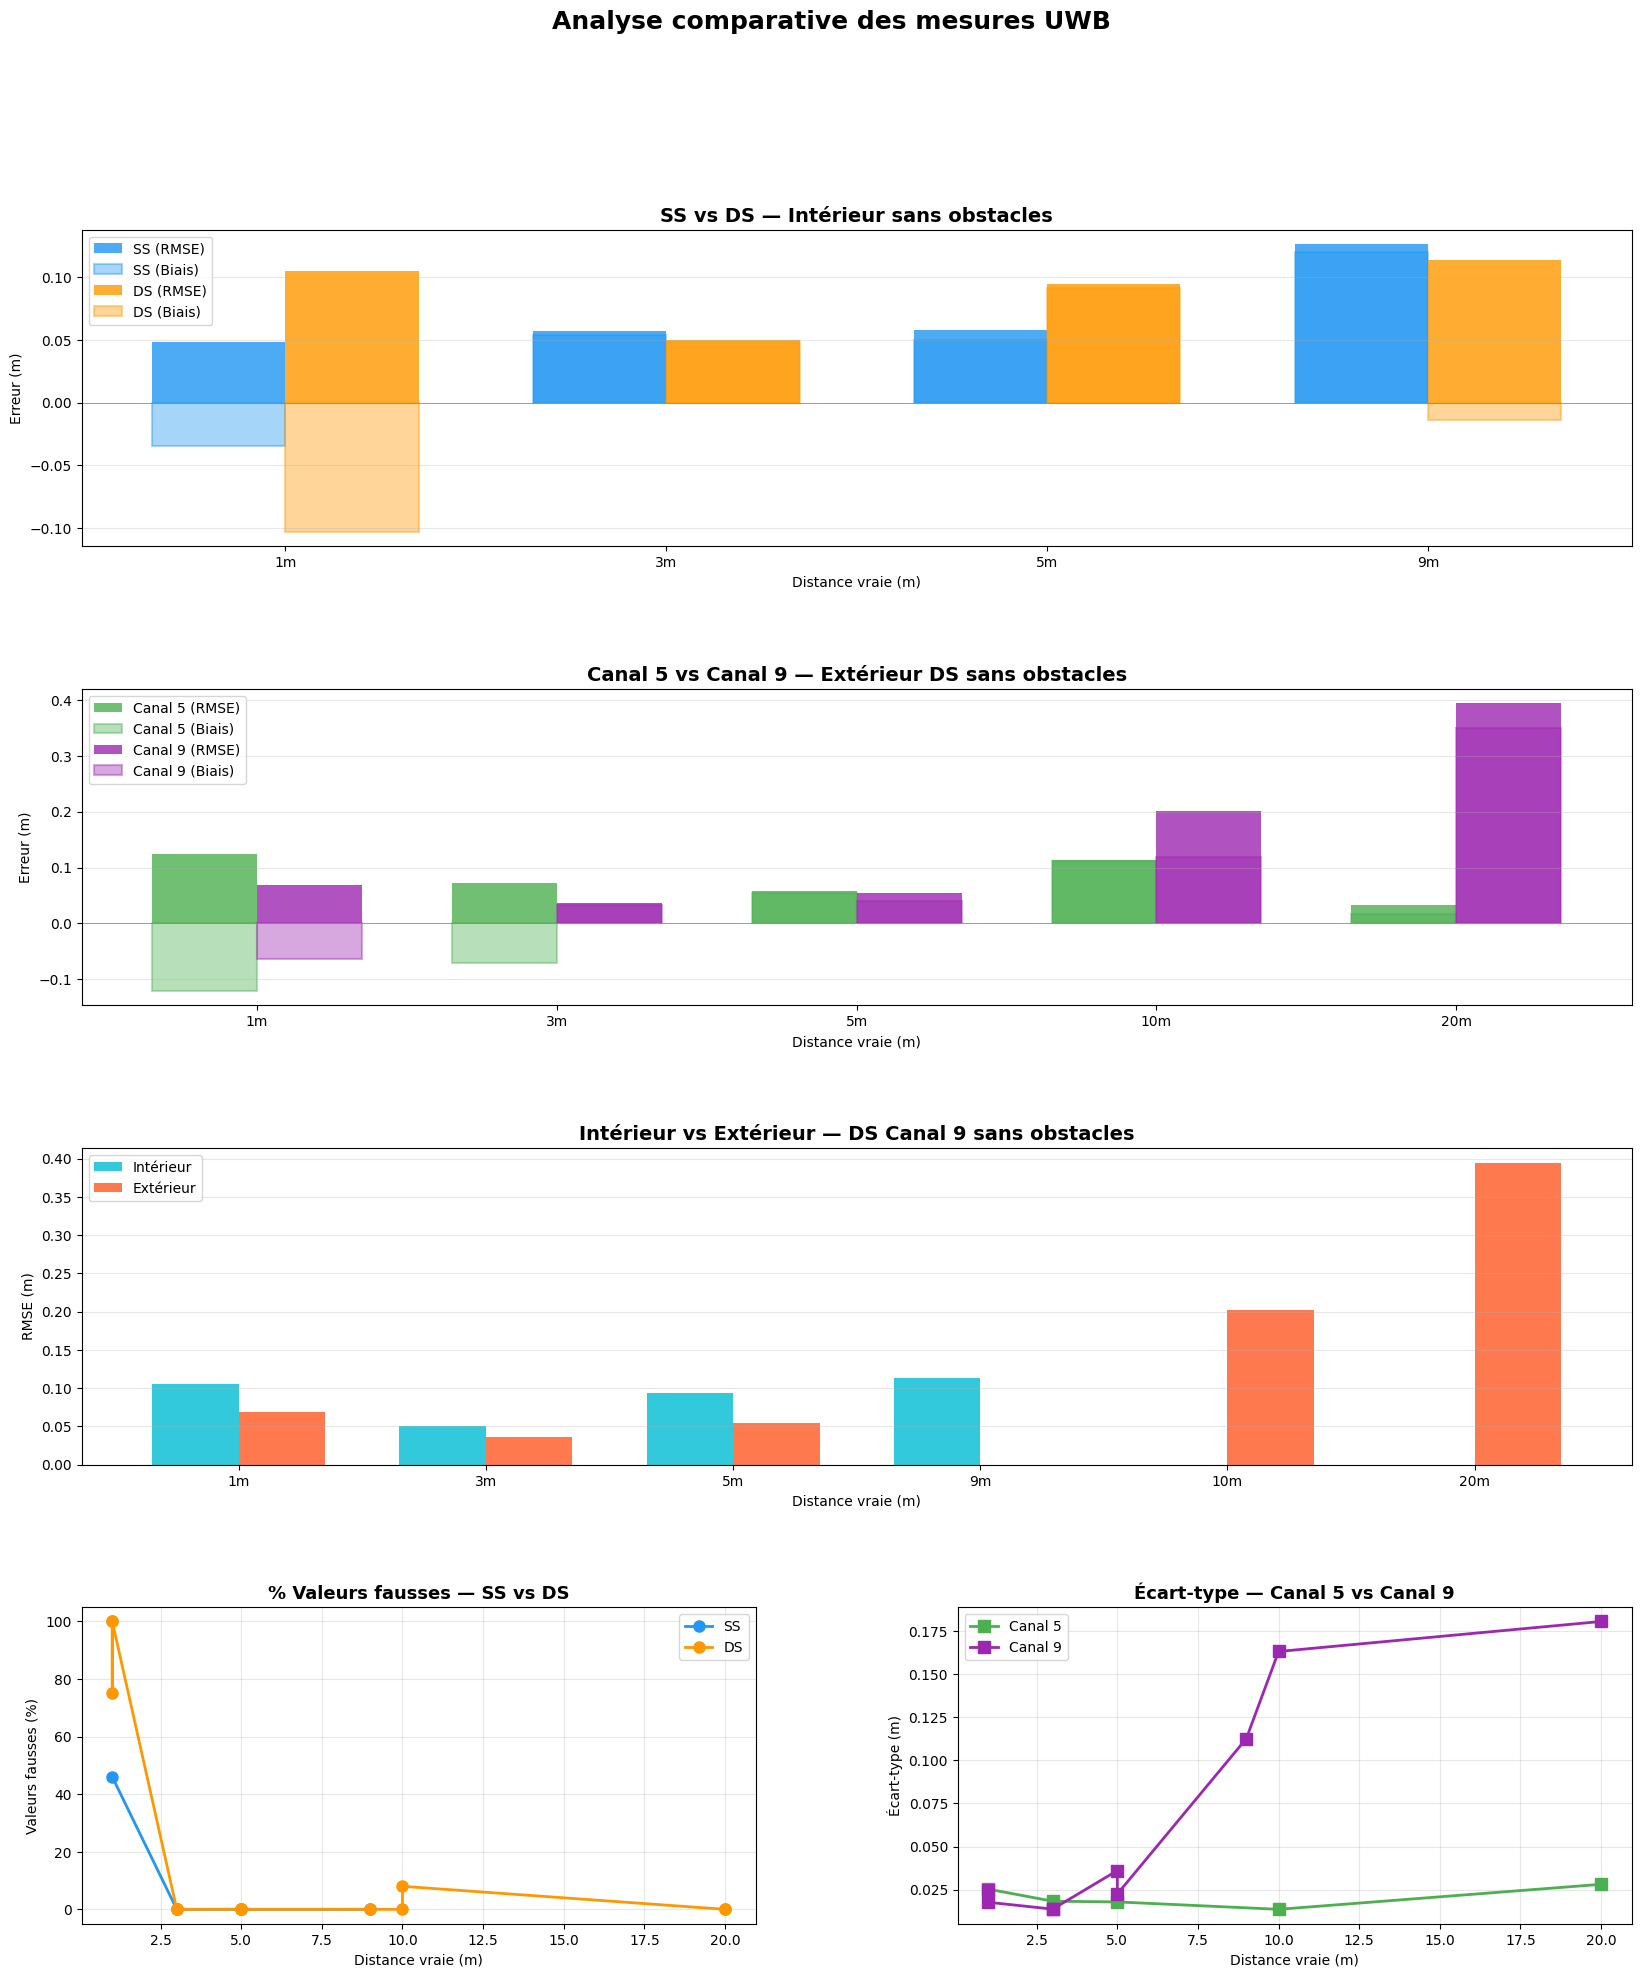


Figure sauvegardée : comparaison_uwb.png


In [28]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# === Classification automatique de chaque fichier ===
def classifier(chemin):
    chemin_lower = chemin.lower()
    
    # Environnement
    if "extérieur" in chemin_lower or "exterieur" in chemin_lower:
        env = "Extérieur"
    elif "intérieur" in chemin_lower or "interieur" in chemin_lower:
        env = "Intérieur"
    else:
        env = "Inconnu"
    
    # Ranging : SS ou DS
    if "single side" in chemin_lower or " ss " in chemin_lower or chemin_lower.startswith("ss "):
        ranging = "SS"
    elif "double side" in chemin_lower or " ds " in chemin_lower:
        ranging = "DS"
    else:
        ranging = "DS"  # par défaut (dossier double side)
    
    # Canal
    if "canal 5" in chemin_lower or "canal5" in chemin_lower:
        canal = "Canal 5"
    elif "canal 9" in chemin_lower or "canal9" in chemin_lower:
        canal = "Canal 9"
    else:
        canal = "Canal 9"  # par défaut pour intérieur
    
    # Obstacle
    if "sans obstacle" in chemin_lower or "sans obsctacle" in chemin_lower:
        obstacle = "Sans obstacle"
    elif "humain" in chemin_lower:
        obstacle = "Obstacle humain"
    elif "métal" in chemin_lower or "metal" in chemin_lower:
        obstacle = "Obstacle métal"
    elif "wifi" in chemin_lower:
        obstacle = "Perturbation WiFi"
    else:
        obstacle = "Autre"
    
    return env, ranging, canal, obstacle

# Enrichir df_stats avec les classifications
df_stats["Environnement"] = df_stats["Fichier"].apply(lambda f: classifier(f)[0])
df_stats["Ranging"] = df_stats["Fichier"].apply(lambda f: classifier(f)[1])
df_stats["Canal"] = df_stats["Fichier"].apply(lambda f: classifier(f)[2])
df_stats["Obstacle"] = df_stats["Fichier"].apply(lambda f: classifier(f)[3])

# Nom court pour les graphiques
def nom_court(fichier):
    parts = fichier.replace("\\", "/").split("/")
    return parts[-1].replace(".csv", "")

df_stats["Nom"] = df_stats["Fichier"].apply(nom_court)

print("Classification des fichiers :")
print(df_stats[["Nom", "Distance vraie (m)", "Environnement", "Ranging", "Canal", "Obstacle"]].to_string(index=False))

# === GRAPHIQUES COMPARATIFS ===
couleurs = {"SS": "#2196F3", "DS": "#FF9800"}
couleurs_canal = {"Canal 5": "#4CAF50", "Canal 9": "#9C27B0"}
couleurs_env = {"Intérieur": "#00BCD4", "Extérieur": "#FF5722"}

fig = plt.figure(figsize=(20, 22))
fig.suptitle("Analyse comparative des mesures UWB", fontsize=18, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(4, 2, hspace=0.45, wspace=0.3)

# --- 1. SS vs DS (intérieur, sans obstacles) ---
ax1 = fig.add_subplot(gs[0, :])
mask_ranging = (df_stats["Environnement"] == "Intérieur") & (df_stats["Obstacle"] == "Sans obstacle")
df_ranging = df_stats[mask_ranging].copy()

if not df_ranging.empty:
    distances = sorted(df_ranging["Distance vraie (m)"].unique())
    x = np.arange(len(distances))
    width = 0.35
    for i, ranging in enumerate(["SS", "DS"]):
        subset = df_ranging[df_ranging["Ranging"] == ranging]
        vals_rmse = []
        vals_biais = []
        for d in distances:
            s = subset[subset["Distance vraie (m)"] == d]
            vals_rmse.append(s["RMSE (m)"].values[0] if len(s) > 0 else 0)
            vals_biais.append(s["Biais (m)"].values[0] if len(s) > 0 else 0)
        ax1.bar(x + i * width, vals_rmse, width, label=f"{ranging} (RMSE)", color=couleurs[ranging], alpha=0.8)
        ax1.bar(x + i * width, vals_biais, width, label=f"{ranging} (Biais)", color=couleurs[ranging], alpha=0.4, edgecolor=couleurs[ranging], linewidth=1.5)
    ax1.set_xlabel("Distance vraie (m)")
    ax1.set_ylabel("Erreur (m)")
    ax1.set_title("SS vs DS — Intérieur sans obstacles", fontsize=14, fontweight="bold")
    ax1.set_xticks(x + width / 2)
    ax1.set_xticklabels([f"{int(d)}m" for d in distances])
    ax1.legend()
    ax1.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
    ax1.grid(axis='y', alpha=0.3)

# --- 2. Canal 5 vs Canal 9 (extérieur, DS, sans obstacles) ---
ax2 = fig.add_subplot(gs[1, :])
mask_canal = (df_stats["Environnement"] == "Extérieur") & (df_stats["Obstacle"] == "Sans obstacle") & (df_stats["Ranging"] == "DS")
df_canal = df_stats[mask_canal].copy()

if not df_canal.empty:
    distances = sorted(df_canal["Distance vraie (m)"].unique())
    x = np.arange(len(distances))
    width = 0.35
    for i, canal in enumerate(["Canal 5", "Canal 9"]):
        subset = df_canal[df_canal["Canal"] == canal]
        vals_rmse = []
        vals_biais = []
        for d in distances:
            s = subset[subset["Distance vraie (m)"] == d]
            vals_rmse.append(s["RMSE (m)"].values[0] if len(s) > 0 else 0)
            vals_biais.append(s["Biais (m)"].values[0] if len(s) > 0 else 0)
        ax2.bar(x + i * width, vals_rmse, width, label=f"{canal} (RMSE)", color=couleurs_canal[canal], alpha=0.8)
        ax2.bar(x + i * width, vals_biais, width, label=f"{canal} (Biais)", color=couleurs_canal[canal], alpha=0.4, edgecolor=couleurs_canal[canal], linewidth=1.5)
    ax2.set_xlabel("Distance vraie (m)")
    ax2.set_ylabel("Erreur (m)")
    ax2.set_title("Canal 5 vs Canal 9 — Extérieur DS sans obstacles", fontsize=14, fontweight="bold")
    ax2.set_xticks(x + width / 2)
    ax2.set_xticklabels([f"{int(d)}m" for d in distances])
    ax2.legend()
    ax2.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
    ax2.grid(axis='y', alpha=0.3)

# --- 3. Intérieur vs Extérieur (DS, canal 9, sans obstacles) ---
ax3 = fig.add_subplot(gs[2, :])
mask_env = (df_stats["Obstacle"] == "Sans obstacle") & (df_stats["Ranging"] == "DS") & (df_stats["Canal"] == "Canal 9")
df_env = df_stats[mask_env].copy()

if not df_env.empty:
    distances = sorted(df_env["Distance vraie (m)"].unique())
    x = np.arange(len(distances))
    width = 0.35
    for i, env in enumerate(["Intérieur", "Extérieur"]):
        subset = df_env[df_env["Environnement"] == env]
        vals_rmse = []
        for d in distances:
            s = subset[subset["Distance vraie (m)"] == d]
            vals_rmse.append(s["RMSE (m)"].values[0] if len(s) > 0 else 0)
        ax3.bar(x + i * width, vals_rmse, width, label=f"{env}", color=couleurs_env[env], alpha=0.8)
    ax3.set_xlabel("Distance vraie (m)")
    ax3.set_ylabel("RMSE (m)")
    ax3.set_title("Intérieur vs Extérieur — DS Canal 9 sans obstacles", fontsize=14, fontweight="bold")
    ax3.set_xticks(x + width / 2)
    ax3.set_xticklabels([f"{int(d)}m" for d in distances])
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)

# --- 4. % Valeurs fausses SS vs DS ---
ax4 = fig.add_subplot(gs[3, 0])
for ranging in ["SS", "DS"]:
    subset = df_stats[(df_stats["Ranging"] == ranging) & (df_stats["Obstacle"] == "Sans obstacle")]
    if not subset.empty:
        subset_sorted = subset.sort_values("Distance vraie (m)")
        ax4.plot(subset_sorted["Distance vraie (m)"], subset_sorted["Valeurs fausses (%)"],
                 'o-', label=ranging, color=couleurs[ranging], linewidth=2, markersize=8)
ax4.set_xlabel("Distance vraie (m)")
ax4.set_ylabel("Valeurs fausses (%)")
ax4.set_title("% Valeurs fausses — SS vs DS", fontsize=13, fontweight="bold")
ax4.legend()
ax4.grid(alpha=0.3)

# --- 5. Écart-type Canal 5 vs Canal 9 ---
ax5 = fig.add_subplot(gs[3, 1])
for canal in ["Canal 5", "Canal 9"]:
    subset = df_stats[(df_stats["Canal"] == canal) & (df_stats["Obstacle"] == "Sans obstacle") & (df_stats["Ranging"] == "DS")]
    if not subset.empty:
        subset_sorted = subset.sort_values("Distance vraie (m)")
        ax5.plot(subset_sorted["Distance vraie (m)"], subset_sorted["Écart-type (m)"],
                 's-', label=canal, color=couleurs_canal[canal], linewidth=2, markersize=8)
ax5.set_xlabel("Distance vraie (m)")
ax5.set_ylabel("Écart-type (m)")
ax5.set_title("Écart-type — Canal 5 vs Canal 9", fontsize=13, fontweight="bold")
ax5.legend()
ax5.grid(alpha=0.3)

plt.savefig(r"C:\Projet-IESE5-Localisation\comparaison_uwb.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nFigure sauvegardée : comparaison_uwb.png")

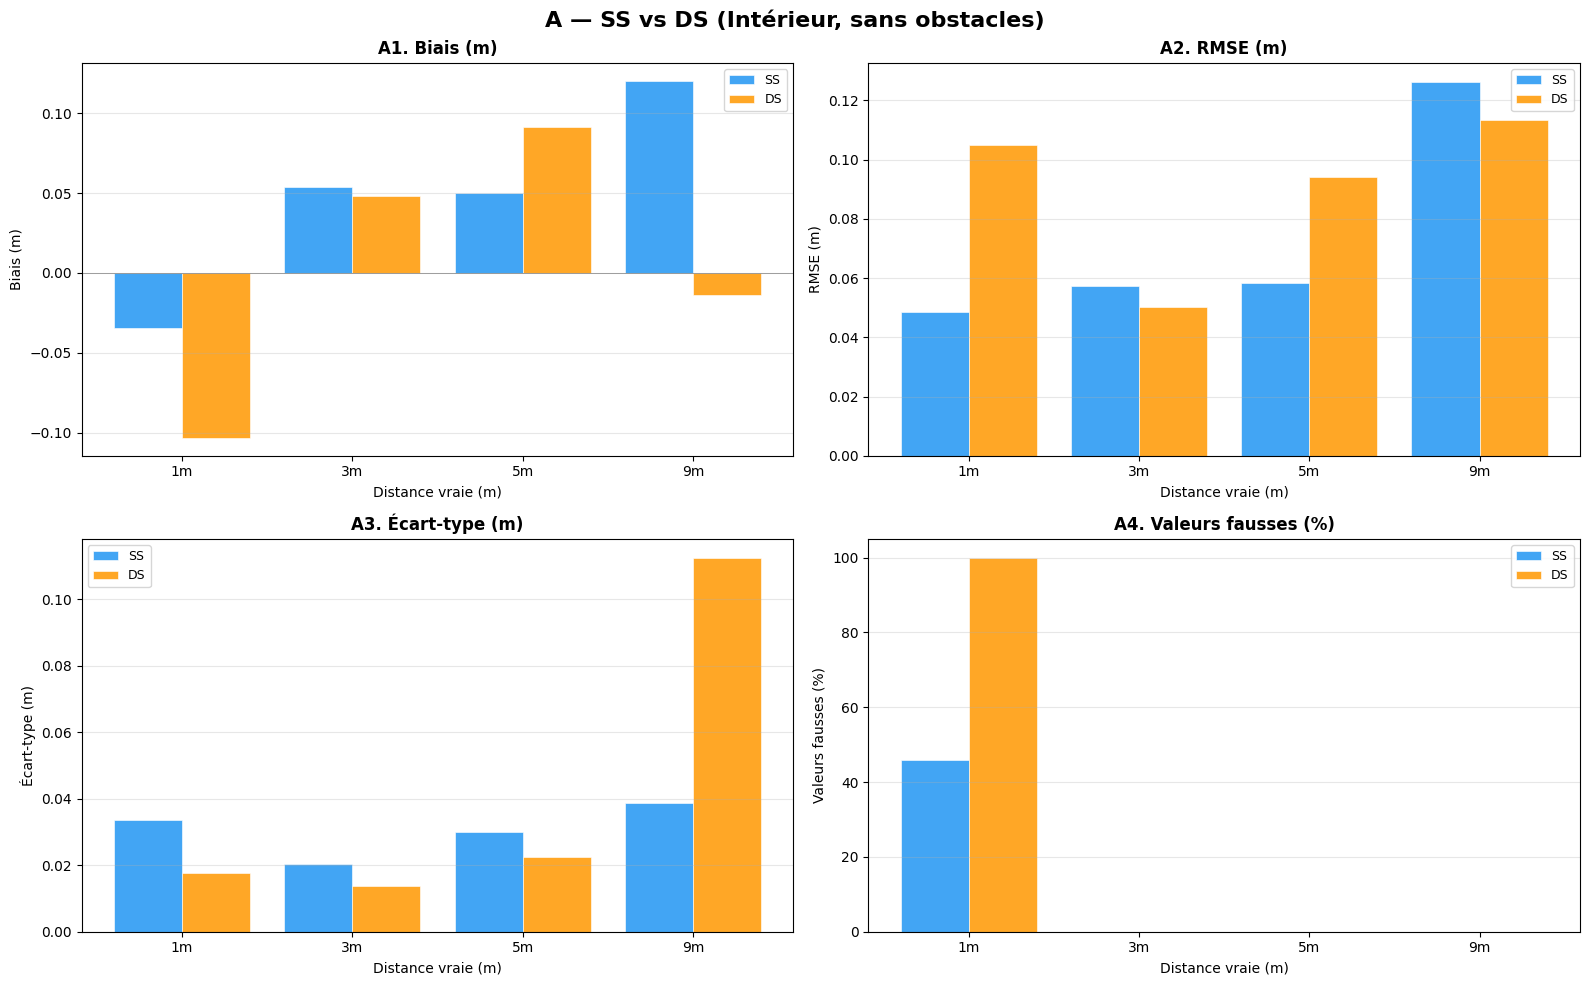

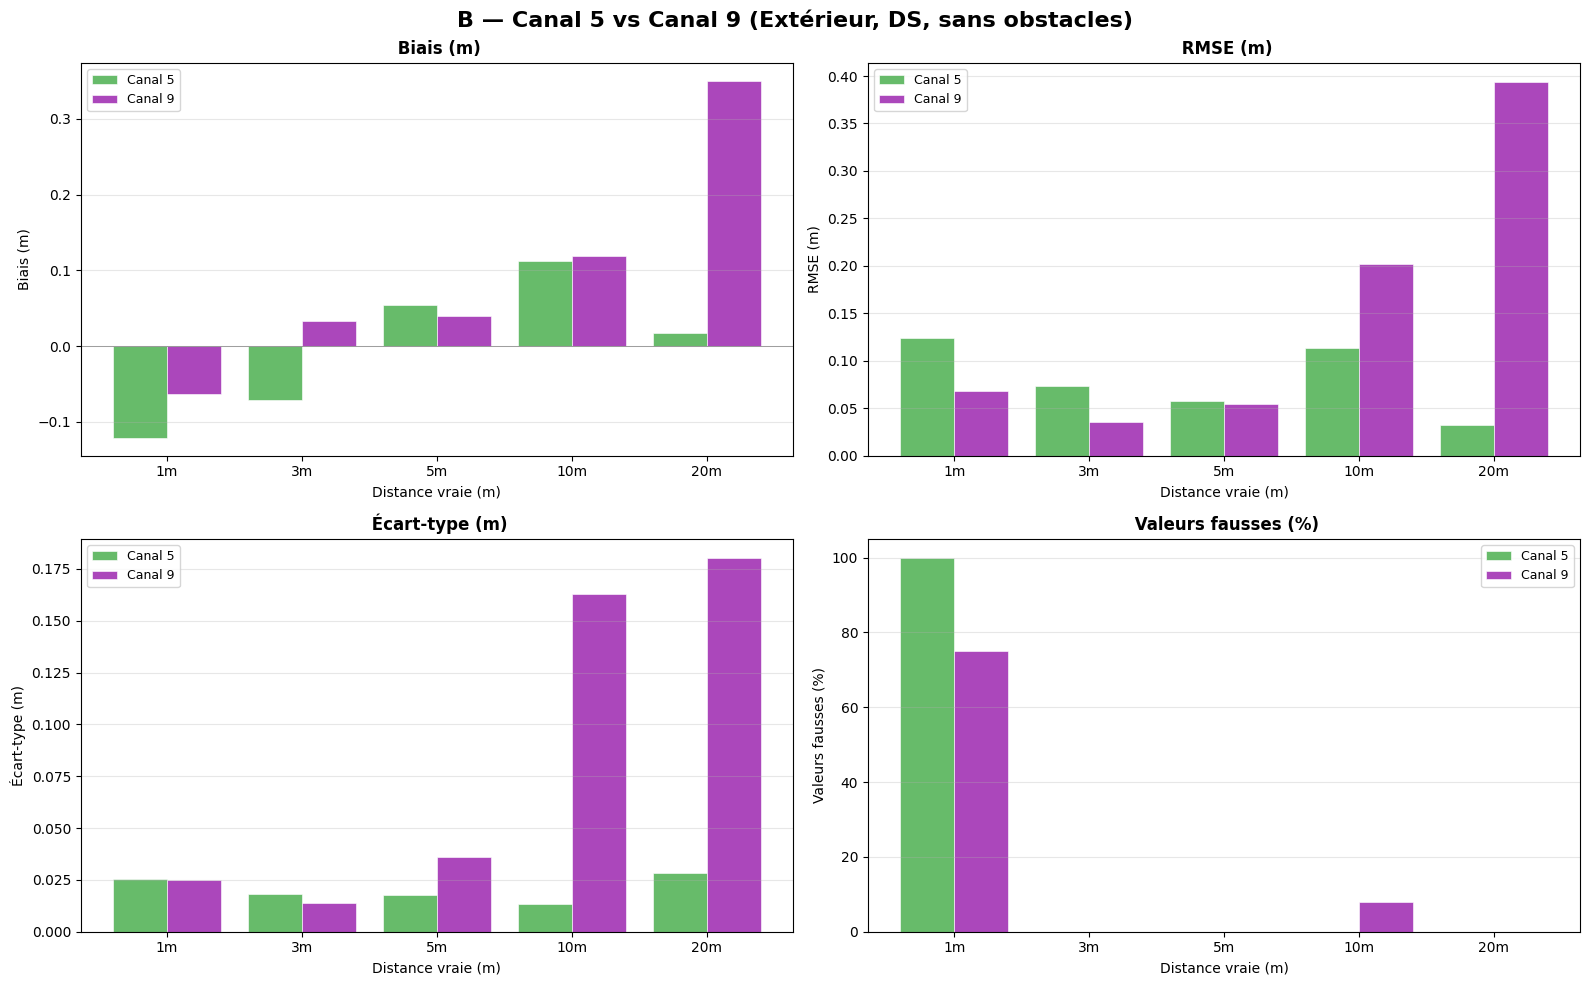

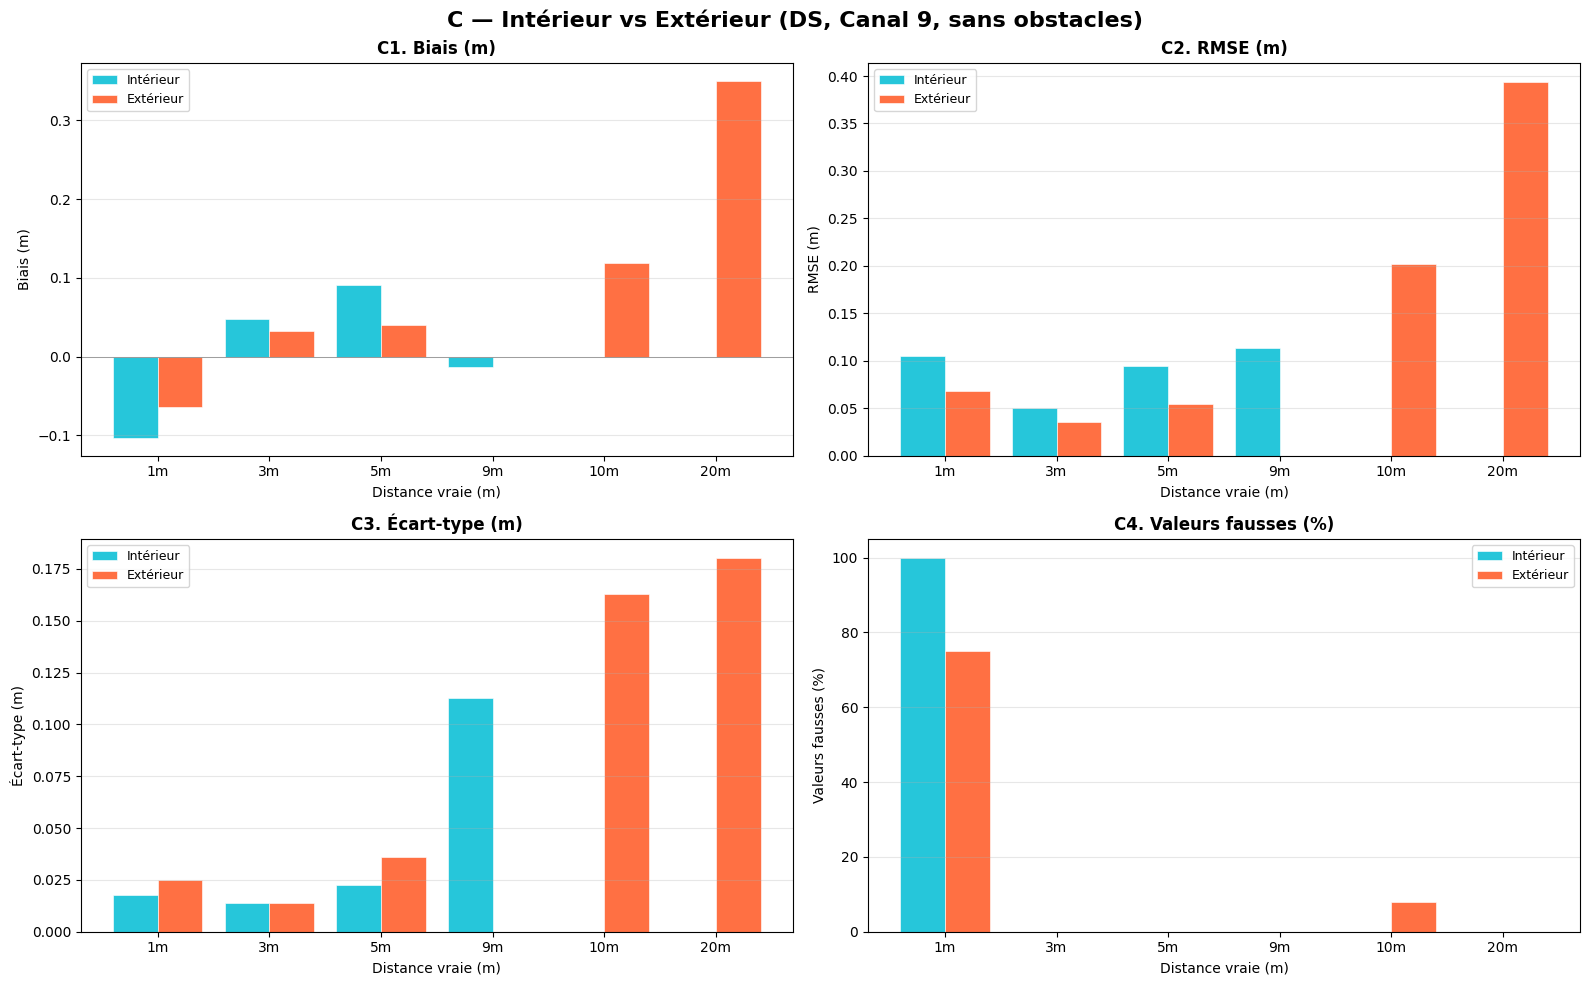

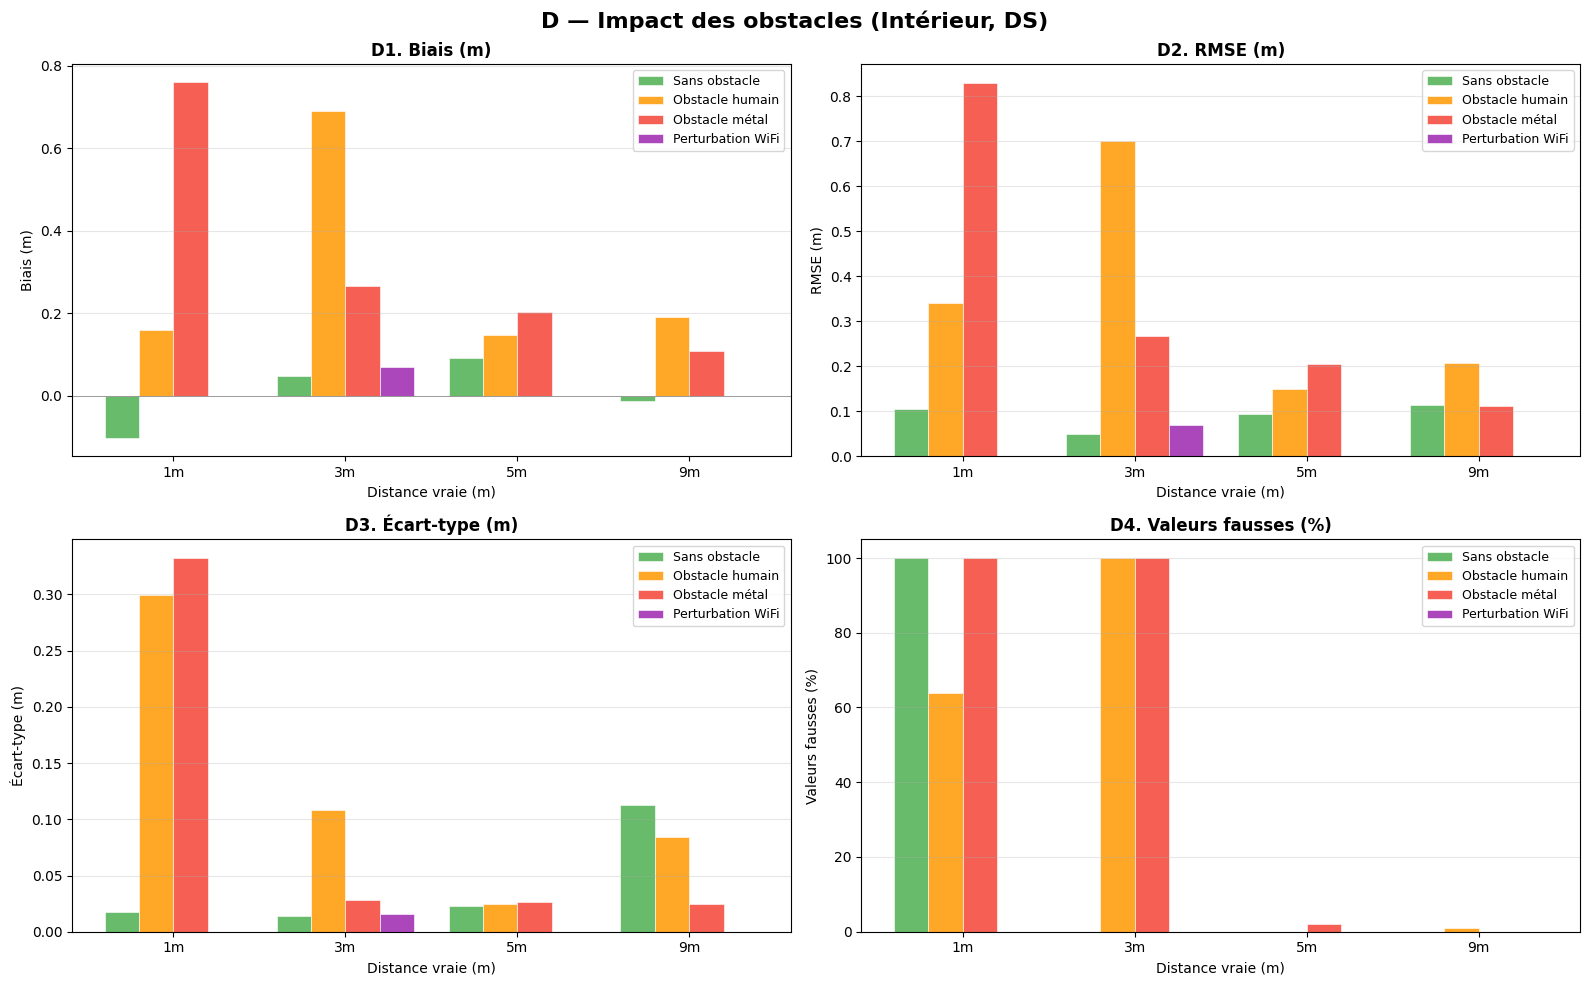

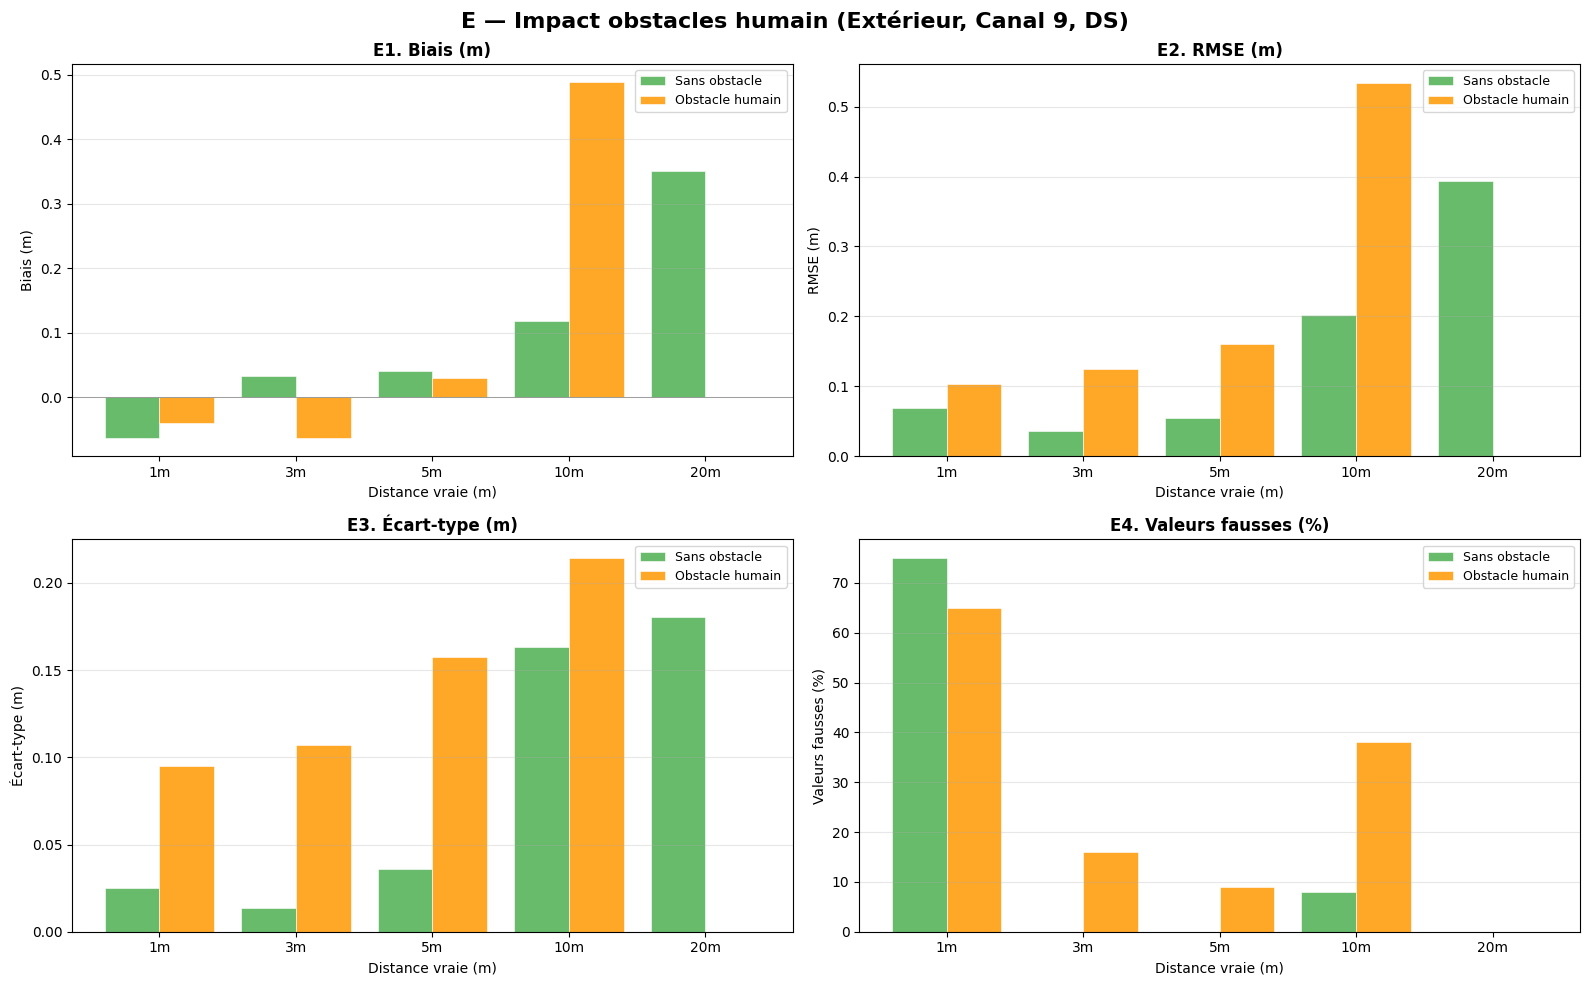

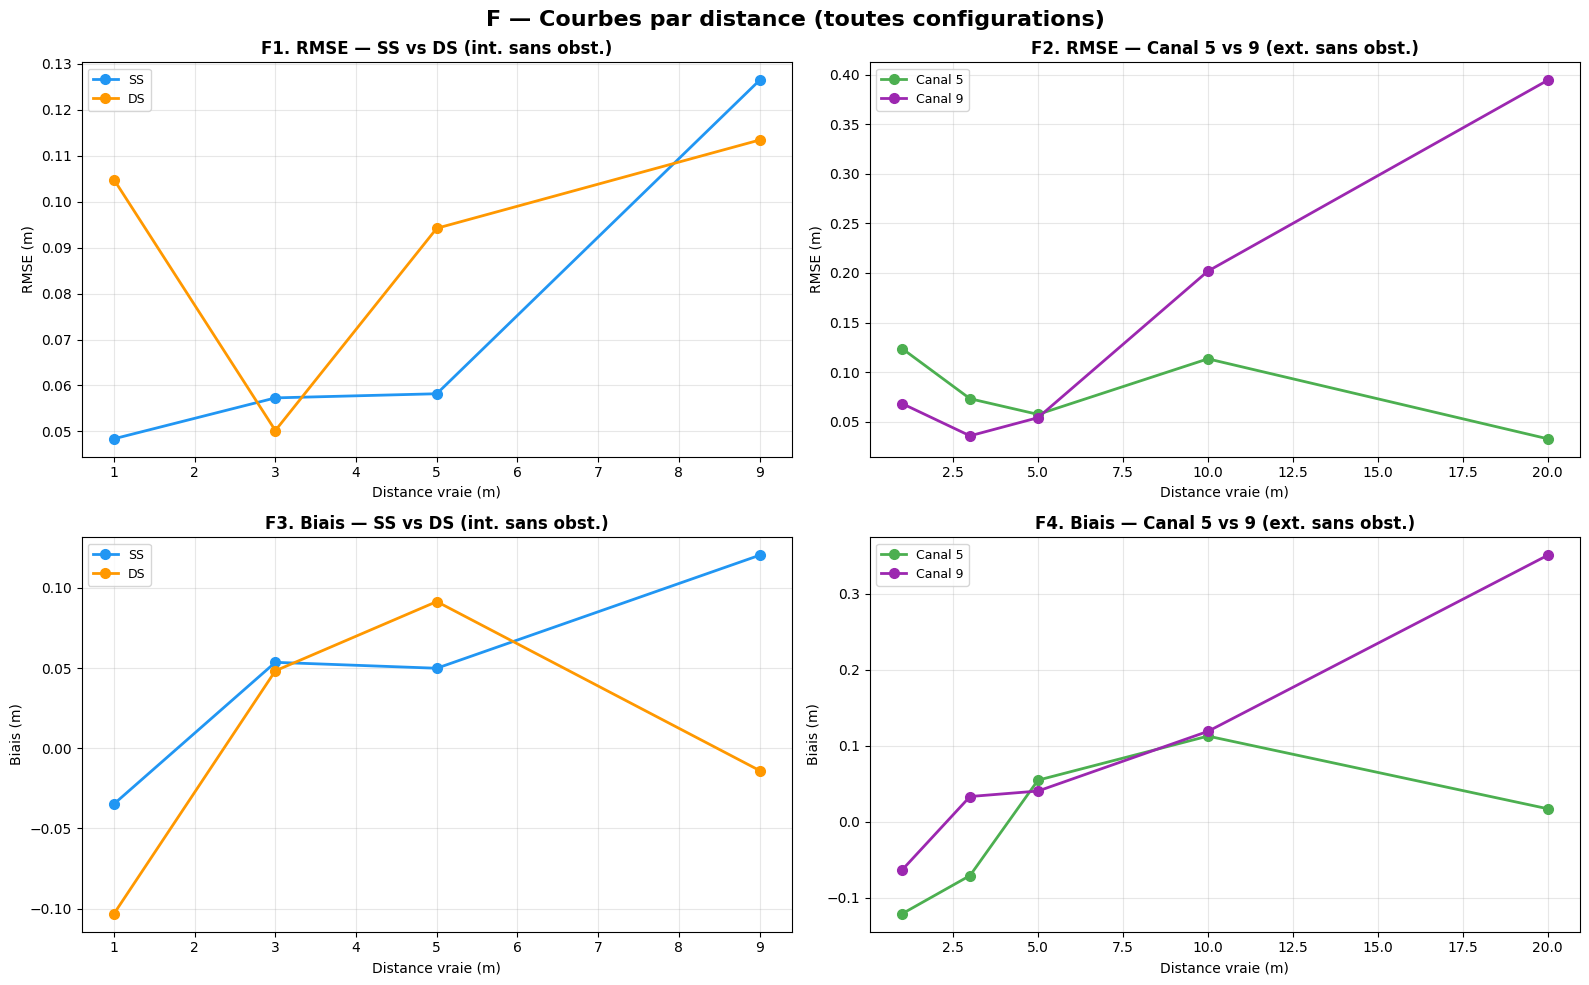

C:\Users\prich\AppData\Local\Temp\ipykernel_29476\494792554.py:176: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(data_ss, labels=[f"{int(d)}m" for d in dists_ss], patch_artist=True)
C:\Users\prich\AppData\Local\Temp\ipykernel_29476\494792554.py:190: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(data_ds, labels=[f"{int(d)}m" for d in dists_ds], patch_artist=True)


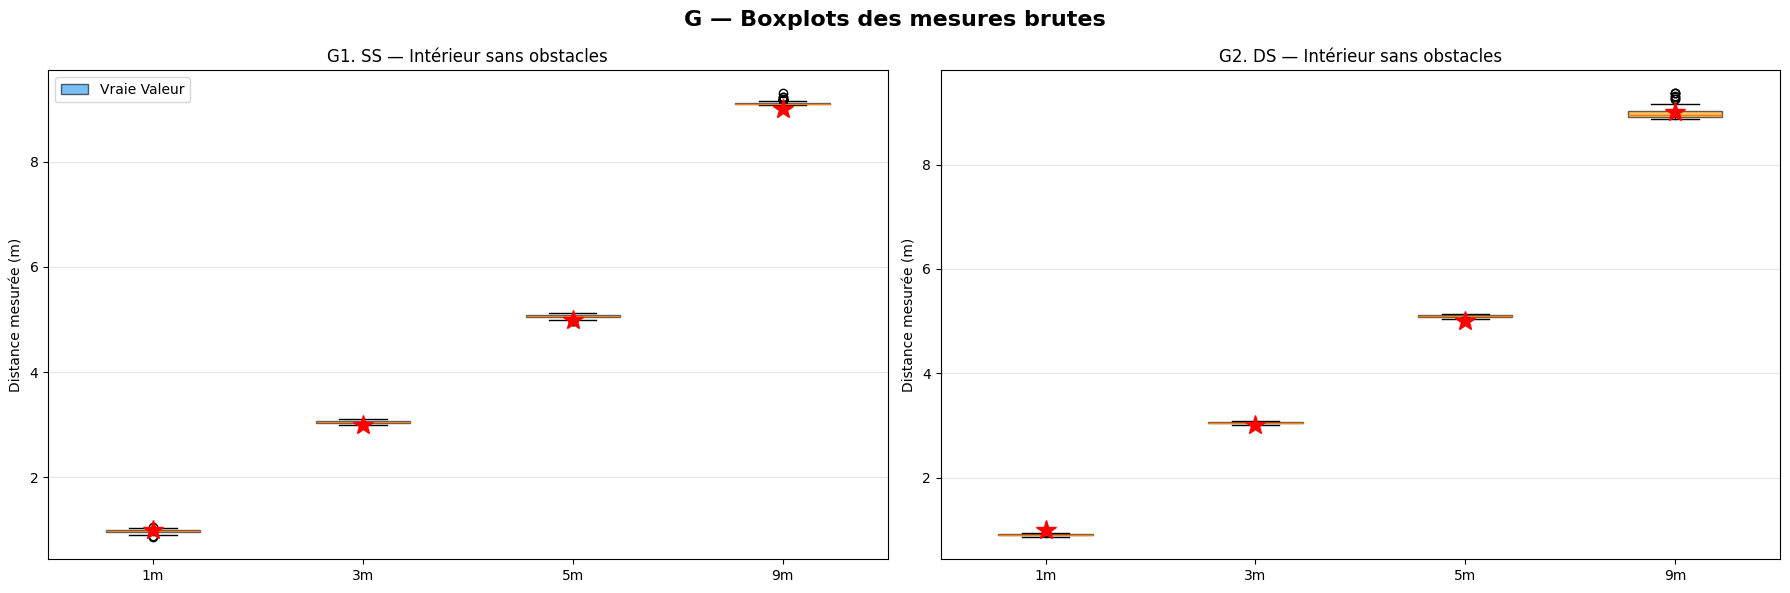

C:\Users\prich\AppData\Local\Temp\ipykernel_29476\494792554.py:215: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_c5, labels=[f"{int(d)}m" for d in dists_c5], patch_artist=True)
C:\Users\prich\AppData\Local\Temp\ipykernel_29476\494792554.py:228: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_c9, labels=[f"{int(d)}m" for d in dists_c9], patch_artist=True)


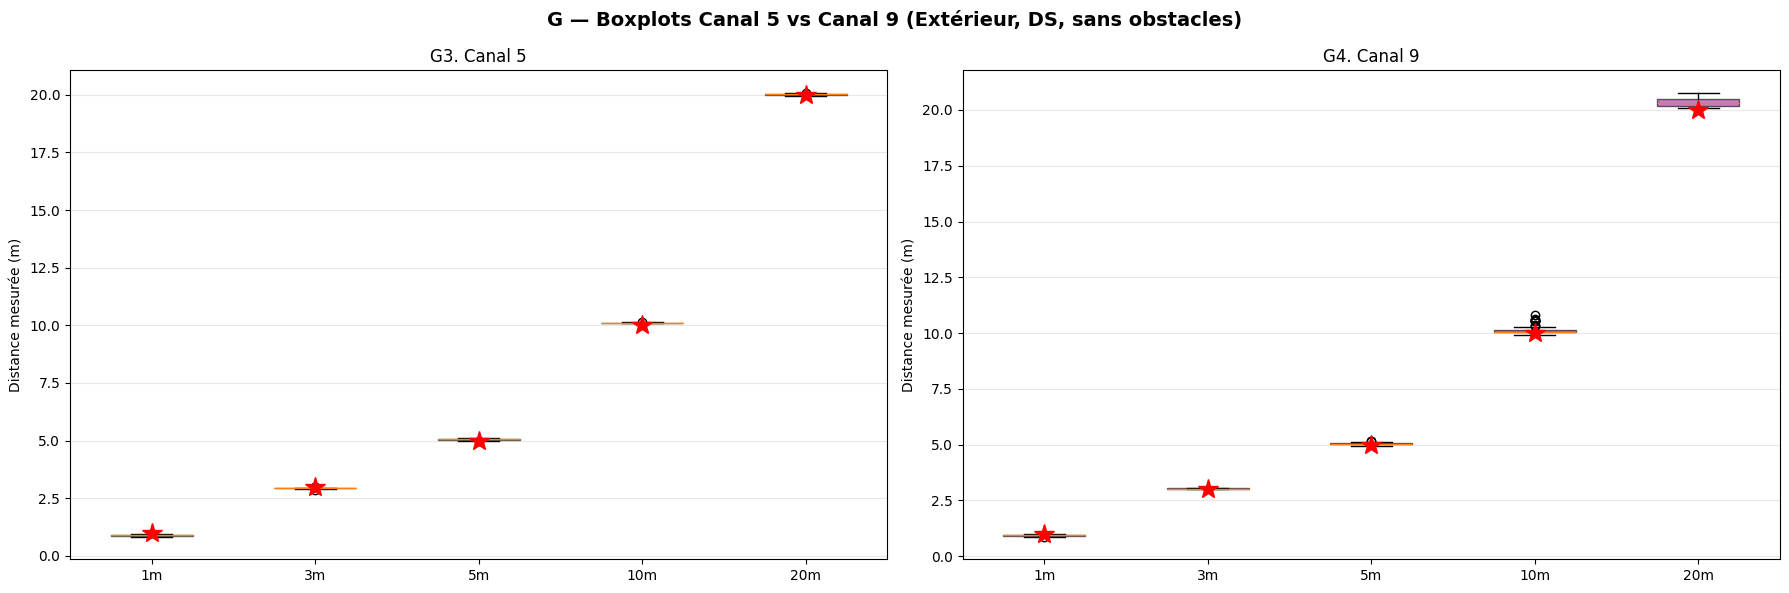

C:\Users\prich\AppData\Local\Temp\ipykernel_29476\494792554.py:254: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_obs, labels=labels_obs, patch_artist=True)


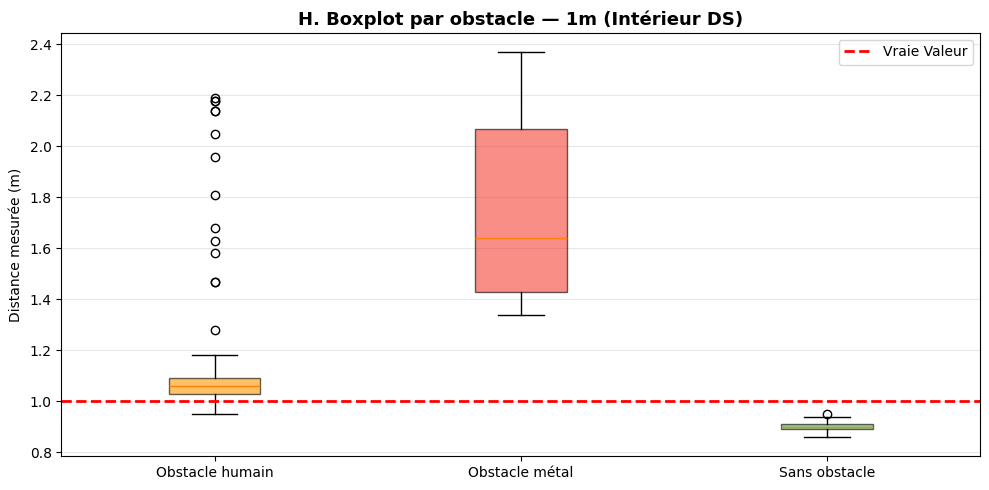

C:\Users\prich\AppData\Local\Temp\ipykernel_29476\494792554.py:254: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_obs, labels=labels_obs, patch_artist=True)


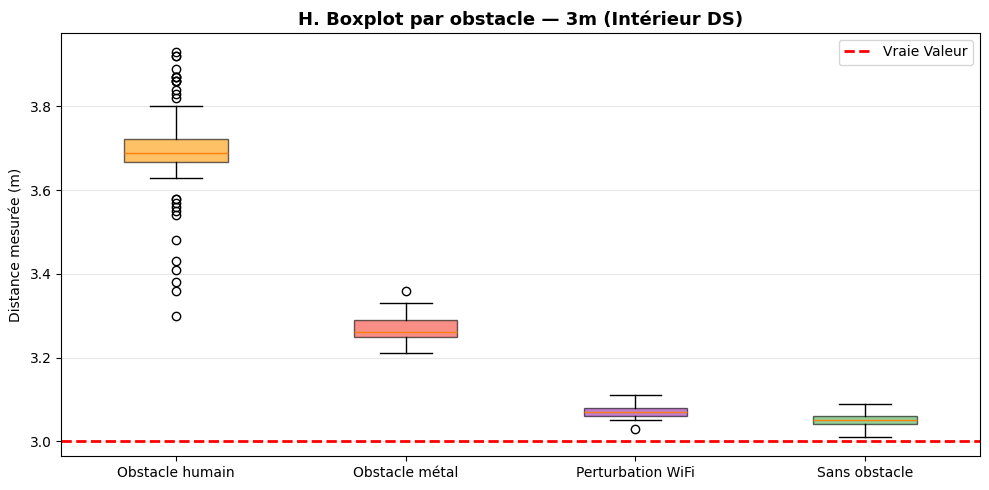

C:\Users\prich\AppData\Local\Temp\ipykernel_29476\494792554.py:254: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_obs, labels=labels_obs, patch_artist=True)


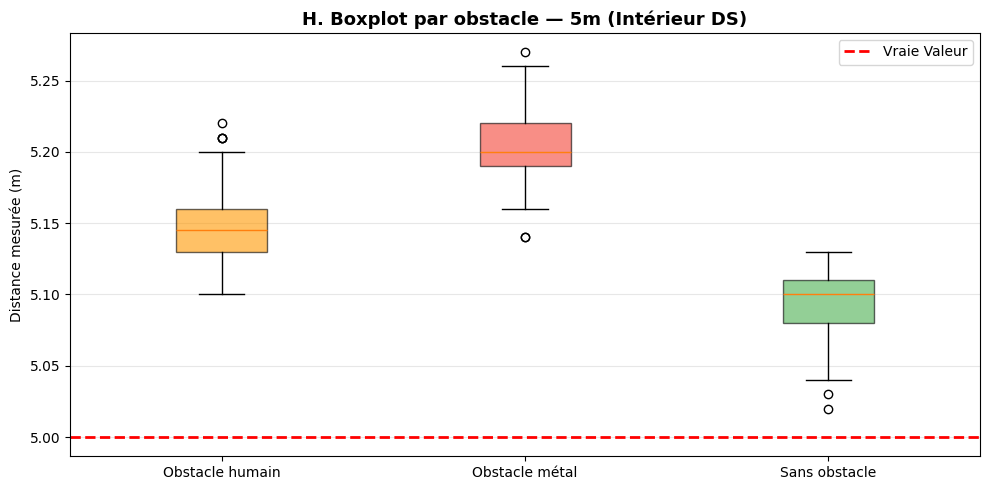

C:\Users\prich\AppData\Local\Temp\ipykernel_29476\494792554.py:254: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_obs, labels=labels_obs, patch_artist=True)


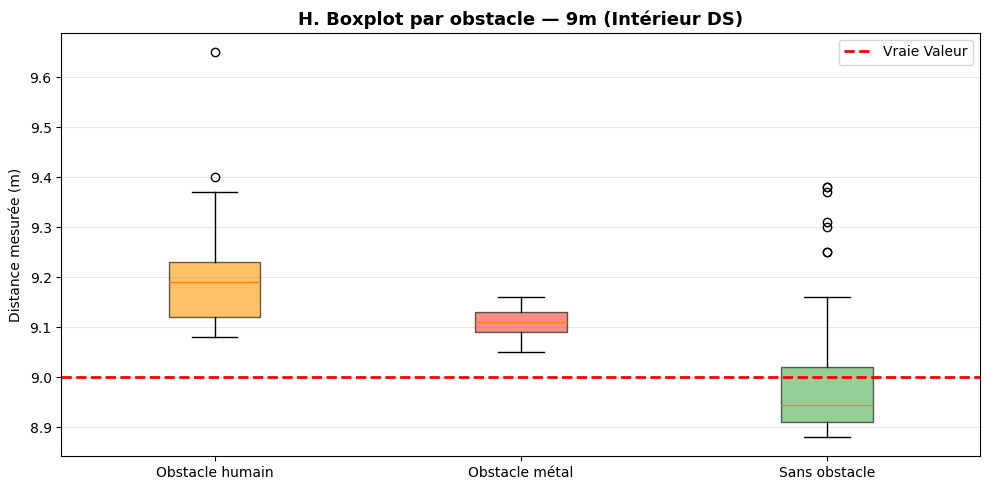

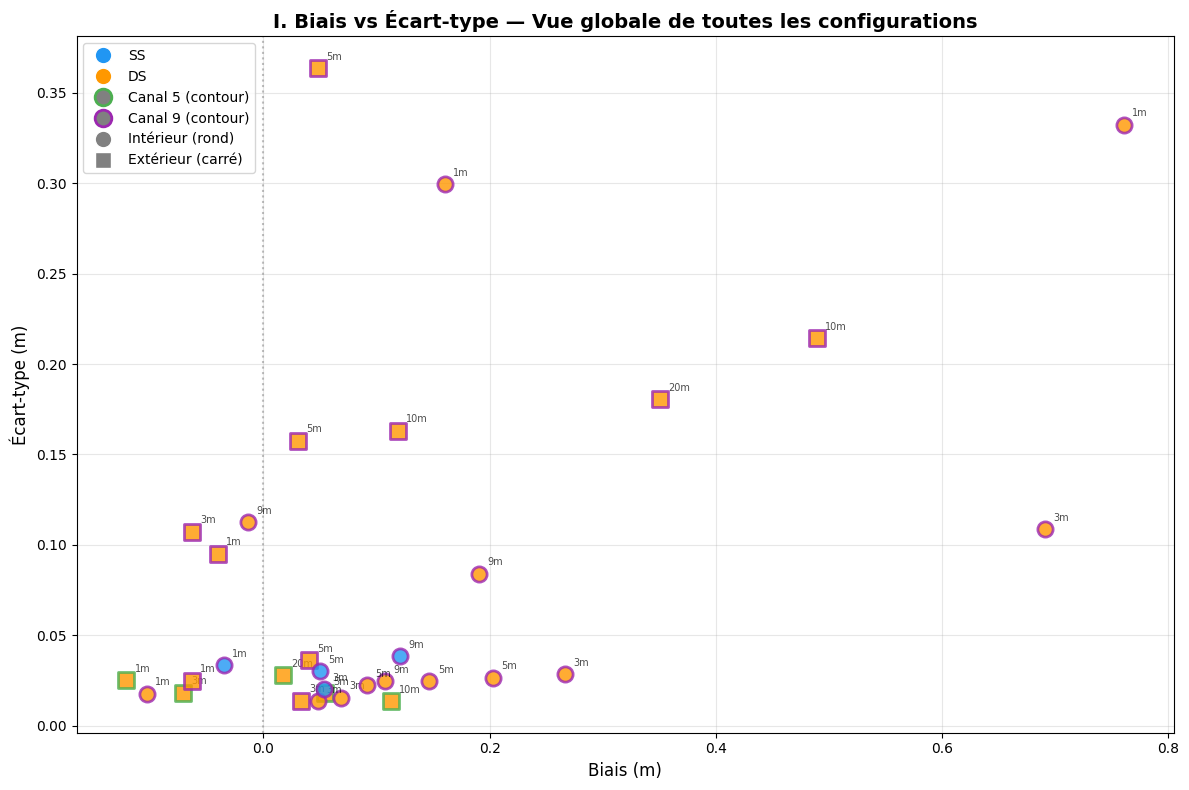

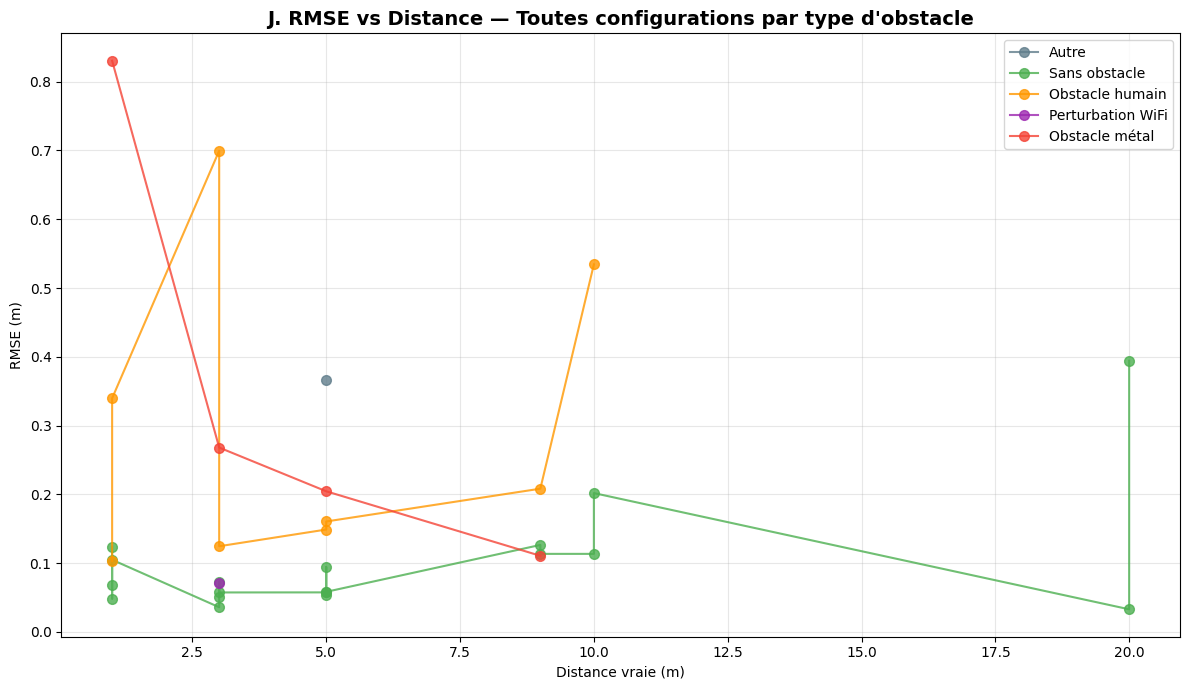

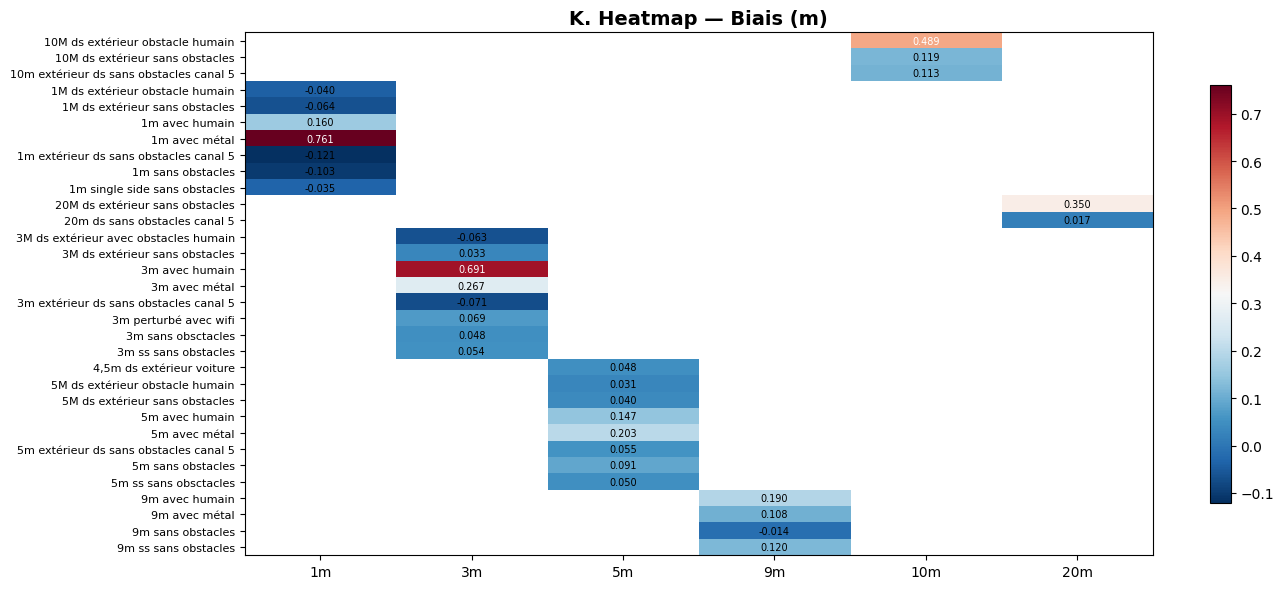

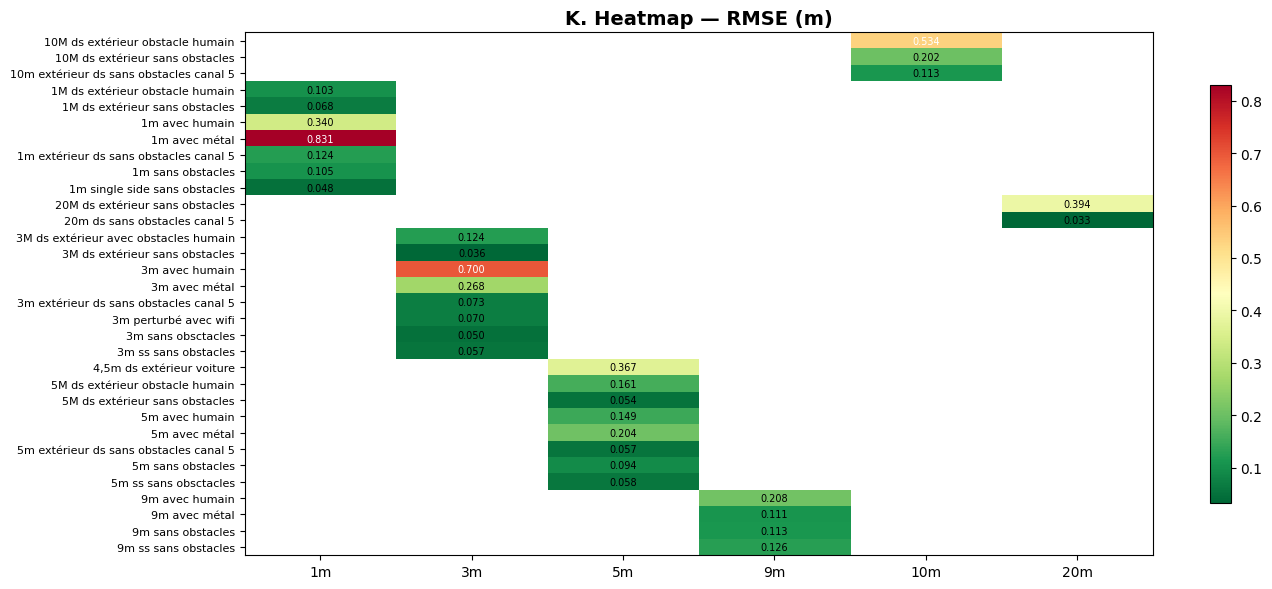

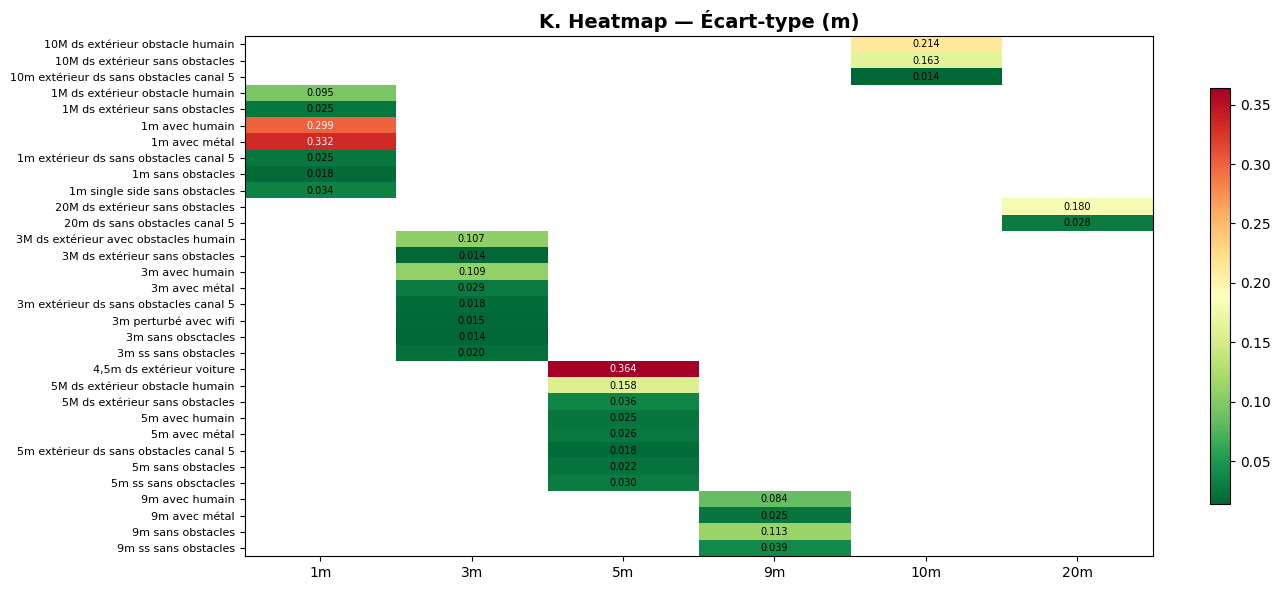

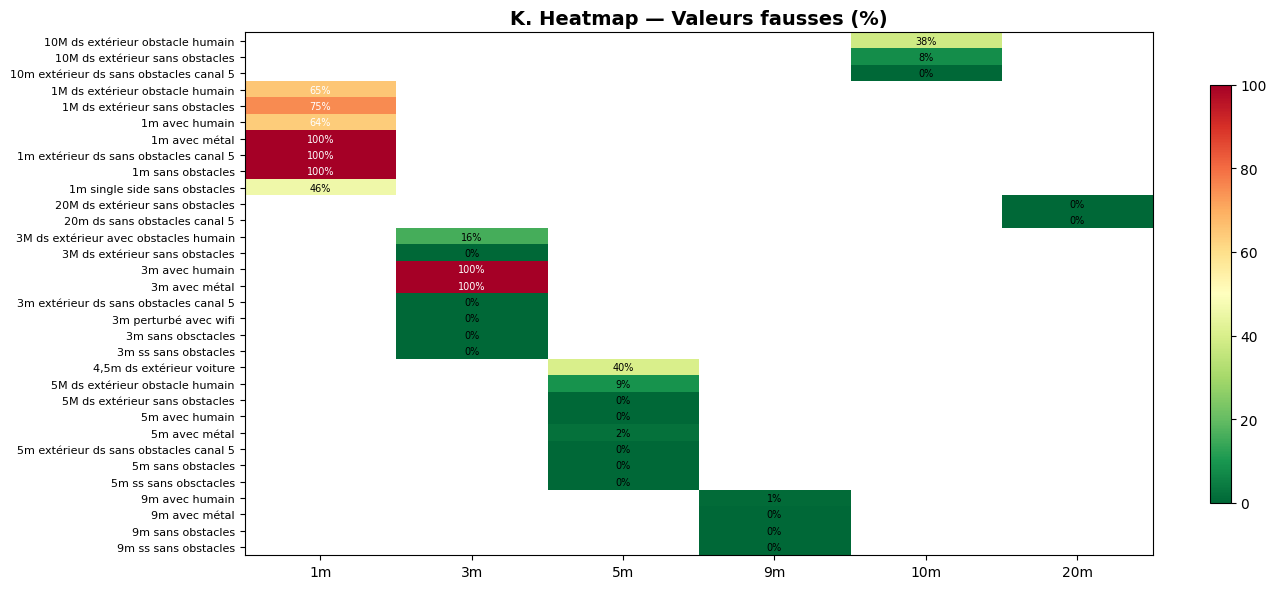

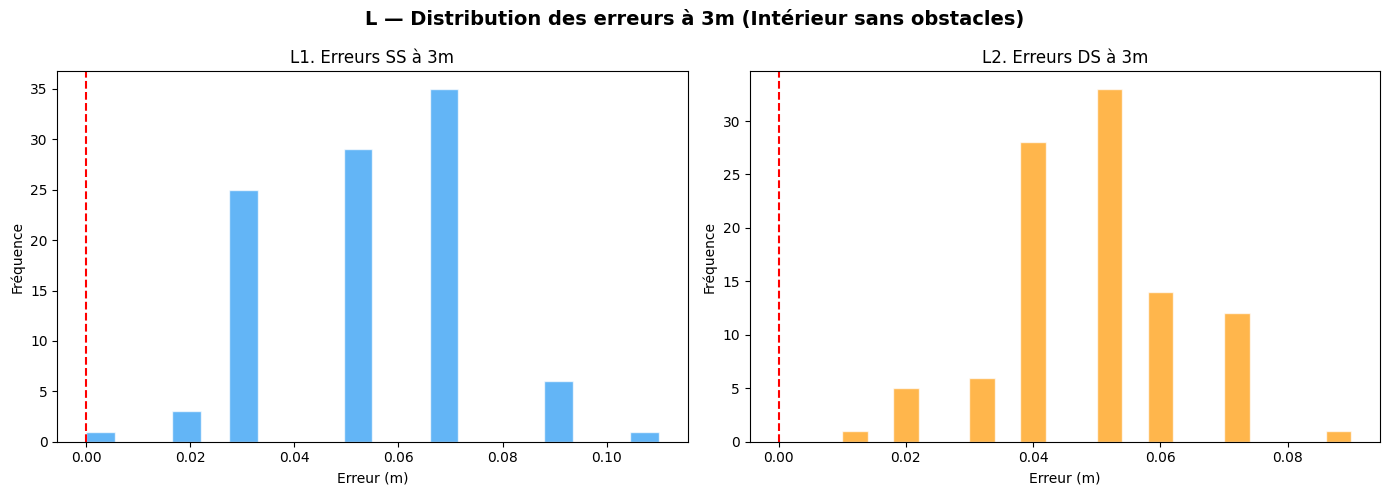

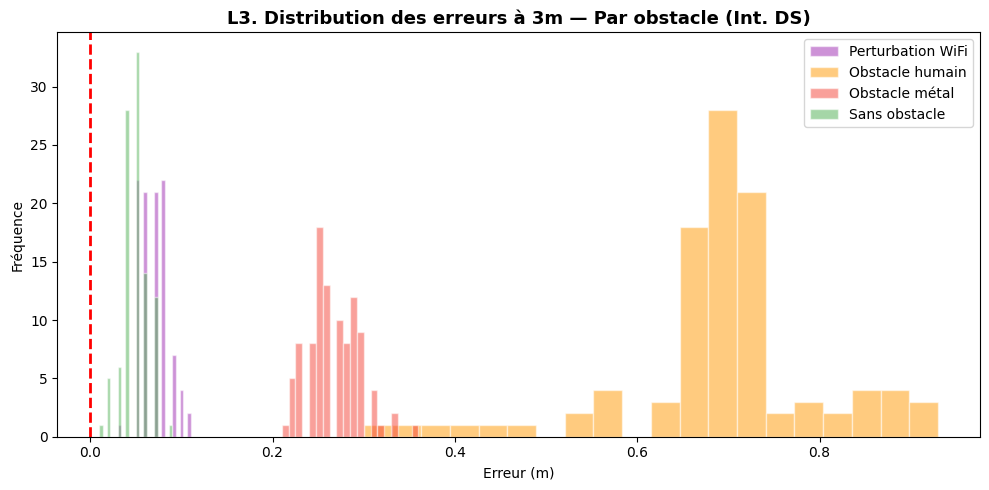


=== TABLEAU RÉCAPITULATIF COMPLET ===

                                    Nom  Distance vraie (m) Environnement Ranging   Canal          Obstacle  Biais (m)  RMSE (m)  Écart-type (m)  Valeurs fausses (%)
 1m extérieur ds sans obstacles canal 5                 1.0     Extérieur      DS Canal 5     Sans obstacle    -0.1212    0.1238          0.0253                100.0
 3m extérieur ds sans obstacles canal 5                 3.0     Extérieur      DS Canal 5     Sans obstacle    -0.0709    0.0732          0.0183                  0.0
 5m extérieur ds sans obstacles canal 5                 5.0     Extérieur      DS Canal 5     Sans obstacle     0.0546    0.0574          0.0179                  0.0
10m extérieur ds sans obstacles canal 5                10.0     Extérieur      DS Canal 5     Sans obstacle     0.1126    0.1134          0.0136                  0.0
          20m ds sans obstacles canal 5                20.0     Extérieur      DS Canal 5     Sans obstacle     0.0170    0.0328  

In [29]:
### === TOUS LES GRAPHIQUES POSSIBLES ===
# Chaque figure est indépendante et numérotée pour faciliter la sélection

metriques_cols = ["Biais (m)", "RMSE (m)", "Écart-type (m)", "Valeurs fausses (%)"]

def bar_comparison(df_sub, group_col, group_vals, colors, metric, title, ax):
    """Barres groupées par distance pour comparer 2+ catégories sur une métrique."""
    distances = sorted(df_sub["Distance vraie (m)"].unique())
    x = np.arange(len(distances))
    n_groups = len(group_vals)
    width = 0.8 / n_groups
    for i, g in enumerate(group_vals):
        subset = df_sub[df_sub[group_col] == g]
        vals = []
        for d in distances:
            s = subset[subset["Distance vraie (m)"] == d]
            vals.append(s[metric].values[0] if len(s) > 0 else 0)
        ax.bar(x + i * width - (n_groups - 1) * width / 2, vals, width,
               label=g, color=colors.get(g, f"C{i}"), alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_xlabel("Distance vraie (m)")
    ax.set_ylabel(metric)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{int(d)}m" for d in distances])
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    if "Biais" in metric:
        ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

def line_comparison(df_sub, group_col, group_vals, colors, metric, title, ax, markers='o-'):
    """Courbes par distance pour comparer 2+ catégories sur une métrique."""
    for g in group_vals:
        subset = df_sub[df_sub[group_col] == g].sort_values("Distance vraie (m)")
        if not subset.empty:
            ax.plot(subset["Distance vraie (m)"], subset[metric],
                    markers, label=g, color=colors.get(g, None), linewidth=2, markersize=7)
    ax.set_xlabel("Distance vraie (m)")
    ax.set_ylabel(metric)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

colors_ranging = {"SS": "#2196F3", "DS": "#FF9800"}
colors_canal = {"Canal 5": "#4CAF50", "Canal 9": "#9C27B0"}
colors_env = {"Intérieur": "#00BCD4", "Extérieur": "#FF5722"}
colors_obstacle = {"Sans obstacle": "#4CAF50", "Obstacle humain": "#FF9800",
                   "Obstacle métal": "#F44336", "Perturbation WiFi": "#9C27B0", "Autre": "#607D8B"}

fig_num = 0

# ============================================================
# SECTION A : SS vs DS (intérieur, sans obstacles) — 4 métriques
# ============================================================
mask_a = (df_stats["Environnement"] == "Intérieur") & (df_stats["Obstacle"] == "Sans obstacle")
df_a = df_stats[mask_a]
if not df_a.empty:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle("A — SS vs DS (Intérieur, sans obstacles)", fontsize=16, fontweight="bold")
    for idx, met in enumerate(metriques_cols):
        ax = axes[idx // 2, idx % 2]
        fig_num += 1
        bar_comparison(df_a, "Ranging", ["SS", "DS"], colors_ranging, met,
                       f"A{idx+1}. {met}", ax)
    plt.tight_layout()
    plt.show()

# ============================================================
# SECTION B : Canal 5 vs Canal 9 (extérieur, DS, sans obstacles) — 4 métriques
# ============================================================
mask_b = (df_stats["Environnement"] == "Extérieur") & (df_stats["Obstacle"] == "Sans obstacle") & (df_stats["Ranging"] == "DS")
df_b = df_stats[mask_b]
if not df_b.empty:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle("B — Canal 5 vs Canal 9 (Extérieur, DS, sans obstacles)", fontsize=16, fontweight="bold")
    for idx, met in enumerate(metriques_cols):
        ax = axes[idx // 2, idx % 2]
        fig_num += 1
        bar_comparison(df_b, "Canal", ["Canal 5", "Canal 9"], colors_canal, met,
                       f" {met}", ax)
    plt.tight_layout()
    plt.show()

# ============================================================
# SECTION C : Intérieur vs Extérieur (DS, canal 9, sans obstacles) — 4 métriques
# ============================================================
mask_c = (df_stats["Obstacle"] == "Sans obstacle") & (df_stats["Ranging"] == "DS") & (df_stats["Canal"] == "Canal 9")
df_c = df_stats[mask_c]
if not df_c.empty:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle("C — Intérieur vs Extérieur (DS, Canal 9, sans obstacles)", fontsize=16, fontweight="bold")
    for idx, met in enumerate(metriques_cols):
        ax = axes[idx // 2, idx % 2]
        fig_num += 1
        bar_comparison(df_c, "Environnement", ["Intérieur", "Extérieur"], colors_env, met,
                       f"C{idx+1}. {met}", ax)
    plt.tight_layout()
    plt.show()

# ============================================================
# SECTION D : Impact obstacles — Intérieur DS — 4 métriques
# ============================================================
mask_d = (df_stats["Environnement"] == "Intérieur") & (df_stats["Ranging"] == "DS")
df_d = df_stats[mask_d]
obstacles_int = [o for o in ["Sans obstacle", "Obstacle humain", "Obstacle métal", "Perturbation WiFi"]
                 if o in df_d["Obstacle"].values]
if len(obstacles_int) > 1:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle("D — Impact des obstacles (Intérieur, DS)", fontsize=16, fontweight="bold")
    for idx, met in enumerate(metriques_cols):
        ax = axes[idx // 2, idx % 2]
        fig_num += 1
        bar_comparison(df_d[df_d["Obstacle"].isin(obstacles_int)], "Obstacle", obstacles_int,
                       colors_obstacle, met, f"D{idx+1}. {met}", ax)
    plt.tight_layout()
    plt.show()

# ============================================================
# SECTION E : Impact obstacles — Extérieur Canal 9 DS — 4 métriques
# ============================================================
mask_e = (df_stats["Environnement"] == "Extérieur") & (df_stats["Canal"] == "Canal 9") & (df_stats["Ranging"] == "DS")
df_e = df_stats[mask_e]
obstacles_ext = [o for o in ["Sans obstacle", "Obstacle humain"] if o in df_e["Obstacle"].values]
if len(obstacles_ext) > 1:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle("E — Impact obstacles humain (Extérieur, Canal 9, DS)", fontsize=16, fontweight="bold")
    for idx, met in enumerate(metriques_cols):
        ax = axes[idx // 2, idx % 2]
        fig_num += 1
        bar_comparison(df_e[df_e["Obstacle"].isin(obstacles_ext)], "Obstacle", obstacles_ext,
                       colors_obstacle, met, f"E{idx+1}. {met}", ax)
    plt.tight_layout()
    plt.show()

# ============================================================
# SECTION F : Courbes RMSE et Biais en fonction de la distance (toutes configs)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("F — Courbes par distance (toutes configurations)", fontsize=16, fontweight="bold")

# F1 : RMSE — SS vs DS (intérieur sans obstacles)
line_comparison(df_a, "Ranging", ["SS", "DS"], colors_ranging, "RMSE (m)",
                "F1. RMSE — SS vs DS (int. sans obst.)", axes[0, 0])

# F2 : RMSE — Canal 5 vs 9 (ext. sans obstacles)
line_comparison(df_b, "Canal", ["Canal 5", "Canal 9"], colors_canal, "RMSE (m)",
                "F2. RMSE — Canal 5 vs 9 (ext. sans obst.)", axes[0, 1])

# F3 : Biais — SS vs DS (intérieur sans obstacles)
line_comparison(df_a, "Ranging", ["SS", "DS"], colors_ranging, "Biais (m)",
                "F3. Biais — SS vs DS (int. sans obst.)", axes[1, 0])

# F4 : Biais — Canal 5 vs 9 (ext. sans obstacles)
line_comparison(df_b, "Canal", ["Canal 5", "Canal 9"], colors_canal, "Biais (m)",
                "F4. Biais — Canal 5 vs 9 (ext. sans obst.)", axes[1, 1])

plt.tight_layout()
plt.show()

# ============================================================
# SECTION G : Boxplots des mesures brutes
# ============================================================

# G1 : Boxplots SS vs DS intérieur sans obstacles
mask_g1_ss = (df_stats["Environnement"] == "Intérieur") & (df_stats["Obstacle"] == "Sans obstacle") & (df_stats["Ranging"] == "SS")
mask_g1_ds = (df_stats["Environnement"] == "Intérieur") & (df_stats["Obstacle"] == "Sans obstacle") & (df_stats["Ranging"] == "DS")
cols_ss = df_stats[mask_g1_ss].sort_values("Distance vraie (m)")["Fichier"].tolist()
cols_ds = df_stats[mask_g1_ds].sort_values("Distance vraie (m)")["Fichier"].tolist()

if cols_ss or cols_ds:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle("G — Boxplots des mesures brutes", fontsize=16, fontweight="bold")
    
    if cols_ss:
        data_ss = [df_mesures[c].dropna().values for c in cols_ss]
        dists_ss = [extraire_distance_vraie(c) for c in cols_ss]
        bp1 = axes[0].boxplot(data_ss, labels=[f"{int(d)}m" for d in dists_ss], patch_artist=True)
        for patch in bp1['boxes']:
            patch.set_facecolor(colors_ranging["SS"])
            patch.set_alpha(0.6)
        # Tracer distance vraie
        for i, d in enumerate(dists_ss):
            axes[0].plot(i + 1, d, 'r*', markersize=15, zorder=5)
        axes[0].set_title("G1. SS — Intérieur sans obstacles")
        axes[0].set_ylabel("Distance mesurée (m)")
        axes[0].grid(axis='y', alpha=0.3)
    
    if cols_ds:
        data_ds = [df_mesures[c].dropna().values for c in cols_ds]
        dists_ds = [extraire_distance_vraie(c) for c in cols_ds]
        bp2 = axes[1].boxplot(data_ds, labels=[f"{int(d)}m" for d in dists_ds], patch_artist=True)
        for patch in bp2['boxes']:
            patch.set_facecolor(colors_ranging["DS"])
            patch.set_alpha(0.6)
        for i, d in enumerate(dists_ds):
            axes[1].plot(i + 1, d, 'r*', markersize=15, zorder=5)
        axes[1].set_title("G2. DS — Intérieur sans obstacles")
        axes[1].set_ylabel("Distance mesurée (m)")
        axes[1].grid(axis='y', alpha=0.3)
    
    axes[0].legend(['Vraie Valeur'], loc='upper left')
    plt.tight_layout()
    plt.show()

# G3-G4 : Boxplots Canal 5 vs Canal 9 (extérieur sans obstacles)
cols_c5 = df_stats[(df_stats["Canal"] == "Canal 5") & (df_stats["Obstacle"] == "Sans obstacle")].sort_values("Distance vraie (m)")["Fichier"].tolist()
cols_c9_ext = df_stats[(df_stats["Canal"] == "Canal 9") & (df_stats["Obstacle"] == "Sans obstacle") & (df_stats["Environnement"] == "Extérieur")].sort_values("Distance vraie (m)")["Fichier"].tolist()

if cols_c5 or cols_c9_ext:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle("G — Boxplots Canal 5 vs Canal 9 (Extérieur, DS, sans obstacles)", fontsize=14, fontweight="bold")
    
    if cols_c5:
        data_c5 = [df_mesures[c].dropna().values for c in cols_c5]
        dists_c5 = [extraire_distance_vraie(c) for c in cols_c5]
        bp = axes[0].boxplot(data_c5, labels=[f"{int(d)}m" for d in dists_c5], patch_artist=True)
        for patch in bp['boxes']:
            patch.set_facecolor(colors_canal["Canal 5"])
            patch.set_alpha(0.6)
        for i, d in enumerate(dists_c5):
            axes[0].plot(i + 1, d, 'r*', markersize=15, zorder=5)
        axes[0].set_title("G3. Canal 5")
        axes[0].set_ylabel("Distance mesurée (m)")
        axes[0].grid(axis='y', alpha=0.3)
    
    if cols_c9_ext:
        data_c9 = [df_mesures[c].dropna().values for c in cols_c9_ext]
        dists_c9 = [extraire_distance_vraie(c) for c in cols_c9_ext]
        bp = axes[1].boxplot(data_c9, labels=[f"{int(d)}m" for d in dists_c9], patch_artist=True)
        for patch in bp['boxes']:
            patch.set_facecolor(colors_canal["Canal 9"])
            patch.set_alpha(0.6)
        for i, d in enumerate(dists_c9):
            axes[1].plot(i + 1, d, 'r*', markersize=15, zorder=5)
        axes[1].set_title("G4. Canal 9")
        axes[1].set_ylabel("Distance mesurée (m)")
        axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ============================================================
# SECTION H : Boxplots par type d'obstacle (intérieur DS)
# ============================================================
distances_obs = sorted(df_d["Distance vraie (m)"].unique())
distances_obs = [d for d in distances_obs if d <= 9]  # garder distances communes

if len(obstacles_int) > 1:
    for dist in distances_obs:
        cols_obs = df_d[(df_d["Distance vraie (m)"] == dist) & (df_d["Obstacle"].isin(obstacles_int))].sort_values("Obstacle")
        if len(cols_obs) > 1:
            fig, ax = plt.subplots(figsize=(10, 5))
            data_obs = [df_mesures[row["Fichier"]].dropna().values for _, row in cols_obs.iterrows()]
            labels_obs = cols_obs["Obstacle"].tolist()
            bp = ax.boxplot(data_obs, labels=labels_obs, patch_artist=True)
            for patch, lbl in zip(bp['boxes'], labels_obs):
                patch.set_facecolor(colors_obstacle.get(lbl, "gray"))
                patch.set_alpha(0.6)
            ax.axhline(y=dist, color='red', linestyle='--', linewidth=2, label='Vraie Valeur')
            ax.set_title(f"H. Boxplot par obstacle — {int(dist)}m (Intérieur DS)", fontsize=13, fontweight="bold")
            ax.set_ylabel("Distance mesurée (m)")
            ax.legend()
            ax.grid(axis='y', alpha=0.3)
            plt.tight_layout()
            plt.show()

# ============================================================
# SECTION I : Scatter Biais vs Écart-type (vue globale)
# ============================================================
fig, ax = plt.subplots(figsize=(12, 8))
for _, row in df_stats.iterrows():
    color = colors_ranging.get(row["Ranging"], "gray")
    marker = 'o' if row["Environnement"] == "Intérieur" else 's'
    edge = colors_canal.get(row["Canal"], "black")
    ax.scatter(row["Biais (m)"], row["Écart-type (m)"],
               c=color, edgecolors=edge, linewidths=2,
               marker=marker, s=120, alpha=0.8, zorder=3)
    ax.annotate(f"{int(row['Distance vraie (m)'])}m", (row["Biais (m)"], row["Écart-type (m)"]),
                textcoords="offset points", xytext=(6, 6), fontsize=7, alpha=0.7)

# Légendes manuelles
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors_ranging["SS"], markersize=12, label='SS'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors_ranging["DS"], markersize=12, label='DS'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markeredgecolor=colors_canal["Canal 5"],
           markeredgewidth=2, markersize=12, label='Canal 5 (contour)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markeredgecolor=colors_canal["Canal 9"],
           markeredgewidth=2, markersize=12, label='Canal 9 (contour)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=12, label='Intérieur (rond)'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=12, label='Extérieur (carré)'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
ax.set_xlabel("Biais (m)", fontsize=12)
ax.set_ylabel("Écart-type (m)", fontsize=12)
ax.set_title("I. Biais vs Écart-type — Vue globale de toutes les configurations", fontsize=14, fontweight="bold")
ax.axvline(x=0, color='gray', linestyle=':', alpha=0.5)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# SECTION J : Scatter RMSE vs Distance vraie (toutes configs)
# ============================================================
fig, ax = plt.subplots(figsize=(12, 7))
for obs in df_stats["Obstacle"].unique():
    sub = df_stats[df_stats["Obstacle"] == obs].sort_values("Distance vraie (m)")
    ax.plot(sub["Distance vraie (m)"], sub["RMSE (m)"], 'o-',
            label=obs, color=colors_obstacle.get(obs, "gray"), linewidth=1.5, markersize=7, alpha=0.8)
ax.set_xlabel("Distance vraie (m)")
ax.set_ylabel("RMSE (m)")
ax.set_title("J. RMSE vs Distance — Toutes configurations par type d'obstacle", fontsize=14, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# SECTION K : Heatmap des métriques
# ============================================================
for met in metriques_cols:
    fig, ax = plt.subplots(figsize=(14, 6))
    pivot = df_stats.pivot_table(index="Nom", columns="Distance vraie (m)", values=met, aggfunc="first")
    pivot = pivot.sort_index()
    cmap = "RdYlGn_r" if "fausses" in met or "RMSE" in met or "cart" in met else "RdBu_r"
    im = ax.imshow(pivot.values, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{int(c)}m" for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=8)
    # Annoter
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.3f}" if "fausses" not in met else f"{val:.0f}%",
                        ha="center", va="center", fontsize=7,
                        color="white" if abs(val) > (pivot.values[~np.isnan(pivot.values)].max() * 0.6) else "black")
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(f"K. Heatmap — {met}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

# ============================================================
# SECTION L : Histogrammes des erreurs (distributions)
# ============================================================
# L1 : SS vs DS à 3m intérieur sans obstacles
mask_l_ss = (df_stats["Environnement"] == "Intérieur") & (df_stats["Obstacle"] == "Sans obstacle") & (df_stats["Ranging"] == "SS") & (df_stats["Distance vraie (m)"] == 3)
mask_l_ds = (df_stats["Environnement"] == "Intérieur") & (df_stats["Obstacle"] == "Sans obstacle") & (df_stats["Ranging"] == "DS") & (df_stats["Distance vraie (m)"] == 3)
f_ss = df_stats[mask_l_ss]["Fichier"].tolist()
f_ds = df_stats[mask_l_ds]["Fichier"].tolist()

if f_ss and f_ds:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("L — Distribution des erreurs à 3m (Intérieur sans obstacles)", fontsize=14, fontweight="bold")
    
    errs_ss = df_mesures[f_ss[0]].dropna().values - 3.0
    errs_ds = df_mesures[f_ds[0]].dropna().values - 3.0
    
    axes[0].hist(errs_ss, bins=20, color=colors_ranging["SS"], alpha=0.7, edgecolor='white')
    axes[0].axvline(x=0, color='red', linestyle='--')
    axes[0].set_title("L1. Erreurs SS à 3m")
    axes[0].set_xlabel("Erreur (m)")
    axes[0].set_ylabel("Fréquence")
    
    axes[1].hist(errs_ds, bins=20, color=colors_ranging["DS"], alpha=0.7, edgecolor='white')
    axes[1].axvline(x=0, color='red', linestyle='--')
    axes[1].set_title("L2. Erreurs DS à 3m")
    axes[1].set_xlabel("Erreur (m)")
    axes[1].set_ylabel("Fréquence")
    
    plt.tight_layout()
    plt.show()

# L3 : Distribution erreurs par obstacle à 3m intérieur DS
mask_l_obs = (df_stats["Environnement"] == "Intérieur") & (df_stats["Ranging"] == "DS") & (df_stats["Distance vraie (m)"] == 3)
df_l_obs = df_stats[mask_l_obs]
if len(df_l_obs) > 1:
    fig, ax = plt.subplots(figsize=(10, 5))
    for _, row in df_l_obs.iterrows():
        errs = df_mesures[row["Fichier"]].dropna().values - 3.0
        ax.hist(errs, bins=20, alpha=0.5, label=row["Obstacle"],
                color=colors_obstacle.get(row["Obstacle"], "gray"), edgecolor='white')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax.set_title("L3. Distribution des erreurs à 3m — Par obstacle (Int. DS)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Erreur (m)")
    ax.set_ylabel("Fréquence")
    ax.legend()
    plt.tight_layout()
    plt.show()

# ============================================================
# SECTION M : Tableau récapitulatif global avec toutes les colonnes
# ============================================================
print("\n=== TABLEAU RÉCAPITULATIF COMPLET ===\n")
cols_display = ["Nom", "Distance vraie (m)", "Environnement", "Ranging", "Canal", "Obstacle",
                "Biais (m)", "RMSE (m)", "Écart-type (m)", "Valeurs fausses (%)"]
print(df_stats[cols_display].sort_values(["Environnement", "Ranging", "Canal", "Obstacle", "Distance vraie (m)"])
      .to_string(index=False))

print(f"\n✅ Total : {fig_num + 20} graphiques générés")